# Confusion Matrix Notebook

In this notebook we will create a confusion matrix for the behavioral responses across our glint experiment, for humans and models. 

Essentially we will create 18 x 18 matrix (familiar) and 4 x 4 matrix (novel), Each value in said matrix will correspond to the amount of times say someone gave the response cat for a cat target trial, dog trial, and so one so forth. This way we can see what are the responses participants give for each target object class.

Of importance, you will need to exclude participants that we excluded during regular preprocessing.

Questions amd predictions:

How Does the response pattern of humans compare to models?

Natural: Models and Humans should align relatively similar

Feature: Models and Humans should align relatively similar

Shape: Models and Humans should display a high degree of dissimilarity 

Models prioritize and use features, whilst humans can use both shape and features. Therefore, we should see that models and humans display a high degree of similarity on the feature conditions whilst displaying a high degree of dissimilarity on the shape condition. 

# Adult Confusion Matrix

### Import packages

In [1]:
# Import Necessary Packages 
import os
import pandas as pd
import glob
import numpy as np
import pdb

### Function 1: create_summary_dataframe

To run this notebook properly, just run each of these functions in their order. For demonstration, we will use the familiar experiment and complete each step using familiar glint

In [ ]:
'''
This function goes through adult behavioral experiments (novel and familiar) and produces two summary dataframes for each experiment
and applies the exclusion criteria to the data for each participant before we create the summary dataframes.
Exclusion criteria 1: Remove No responses
Exclusion criteria 2: Remove RTs less than or equal to 100ms
Exclusion criteria 3: Remove RTs outside mean ± 2*SD
'''

import glob
import pandas as pd

experiments = ['familiar', 'novel'] # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes

def create_summary_dataframe(experiments):

    # Loop through each experiment version (familiar and novel)
    for experiment in experiments:


        # Define the paths 
        base = '/zpool/vladlab/data_drive/glint_master/data/adult_data'
            
        core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

        # if statement to set the list of excluded participants and objects based on which experiment version we are analyzing (familiar or novel)
        if experiment == 'familiar':
            excluded_participants = ['66afcaa60f7d8f58dc21db8e', '66cec5a3fdf1fe2c010e9971']
            objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
        elif experiment == 'novel':
            excluded_participants = ['66a398080da27efcc3e8ecef', '670efd496f9f47e38a4b1d7d', '5aed18cf026e1300018199b3']
            objects = ['krar', 'sarangi', 'sistrum', 'sheng']

        # Initialize empty dataframe
        participant_summary_df = pd.DataFrame()


        
        sub_summary = pd.DataFrame()

        base = '/zpool/vladlab/data_drive/glint_master/data/adult_data'
            
        # import the files
        files = glob.glob(f'{core_path}/*.csv') 
        print(f"You have selected {experiment} glint experiment")

        for obj in objects:
            for file in files:

                # Take the data for one participant at a time
                data = pd.read_csv(file)

                # Check if the participant is in the excluded list
                if data.loc[0, 'participant'] in excluded_participants:
                    continue # skip this participant if they are in the excluded list
                
                '''        
                We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
                Exclusion criteria 1: Remove No responses
                Exclusion criteria 2: Remove RTs less than or equal to 100ms
                Exclusion criteria 3: Remove RTs outside mean ± 2*SD
                
                '''
                # Exclusion criteria 1: Remove No responses
                data_exclusion_1 = data[data['response_label'] != 'no_response']

                # Exclusion criteria 2: Remove RTs less than or equal to 100ms
                data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

                # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
                rt_mean = data_exclusion_2['key_resp.rt'].mean()
                rt_std = data_exclusion_2['key_resp.rt'].std()
                data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]

                # Filter for the current object class
                if experiment == 'familiar':
                    object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
                
                elif experiment == 'novel':
                    object_trials = data_exclusion_3[data_exclusion_3['img_class'] == obj]
                
                # Extract only the columns you want
                if experiment == 'familiar':
                    subset = object_trials[[
                        'participant',
                        'img_condition', # condition (natural, scrambled, line_drawing)
                        'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                        'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                        'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                        'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                        'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                        'key_resp.keys', # The actual key they pressed for their response
                        'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                        'prompt_2', 
                        'prompt_3', 
                        'prompt_4', 
                        'prompt_5', 
                        'prompt_6', 
                        'prompt_7', 
                        'prompt_8', 
                        'prompt_9']].copy()
                    
                if experiment == 'novel':
                    subset = object_trials[[
                        'participant',
                        'condition',
                        'img_class',
                        'response_label', 
                        'key_resp.corr', 
                        'key_resp.keys', 
                        'prompt_1',
                        'prompt_2',
                        'prompt_3',
                        'prompt_4']].copy()
                    
                column_map = {
                    "response_label": "response_by_subject",
                    "key_resp.corr": "correct (0=incorrect, 1=correct)",
                    "key_resp.keys": "keyboard_response",
                    "img_condition": "condition_block",
                    "object_category": "correct_animacy",
                    "img_class": "correct_object_class",
                    "object_class": "correct_object_class",
                    "condition": "condition_block"}

                #rename the columns to standardize across experiment versions
                data = subset.rename(columns=column_map)

                # Append to the summary list
                participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe

            # Combine all into one dataframe
            if experiment == 'familiar':
                familiar_sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)
            
            elif experiment == 'novel':
                novel_sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)

    return familiar_sub_summary, novel_sub_summary

familiar_sub_summary, novel_sub_summary = create_summary_dataframe(experiments)


You have selected familiar glint experiment
You have selected novel glint experiment


### Function 2: create_confusion_matrices

Experiment: Familiar, Condition: natural
natural
response_by_subject   airplane  apple  avocado   bear  binoculars  bread  \
correct_object_class                                                       
airplane                 96.41   0.00     0.51   0.00        0.51   0.00   
apple                     0.00  97.41     0.52   0.00        0.52   0.00   
avocado                   0.00   0.00    96.92   0.00        0.00   0.51   
bear                      0.00   0.00     0.00  96.92        0.00   0.00   
binoculars                0.51   0.00     0.00   0.00       97.97   0.00   
bread                     0.53   0.00     0.00   0.00        0.00  96.30   
butterfly                 0.00   0.00     0.00   0.51        0.00   0.00   
car                       0.00   0.00     0.00   0.00        0.00   0.00   
cat                       0.00   0.00     0.00   0.00        0.00   0.00   
corn                      0.00   0.00     0.00   0.00        0.00   0.00   
cow                       0.00   0.00  

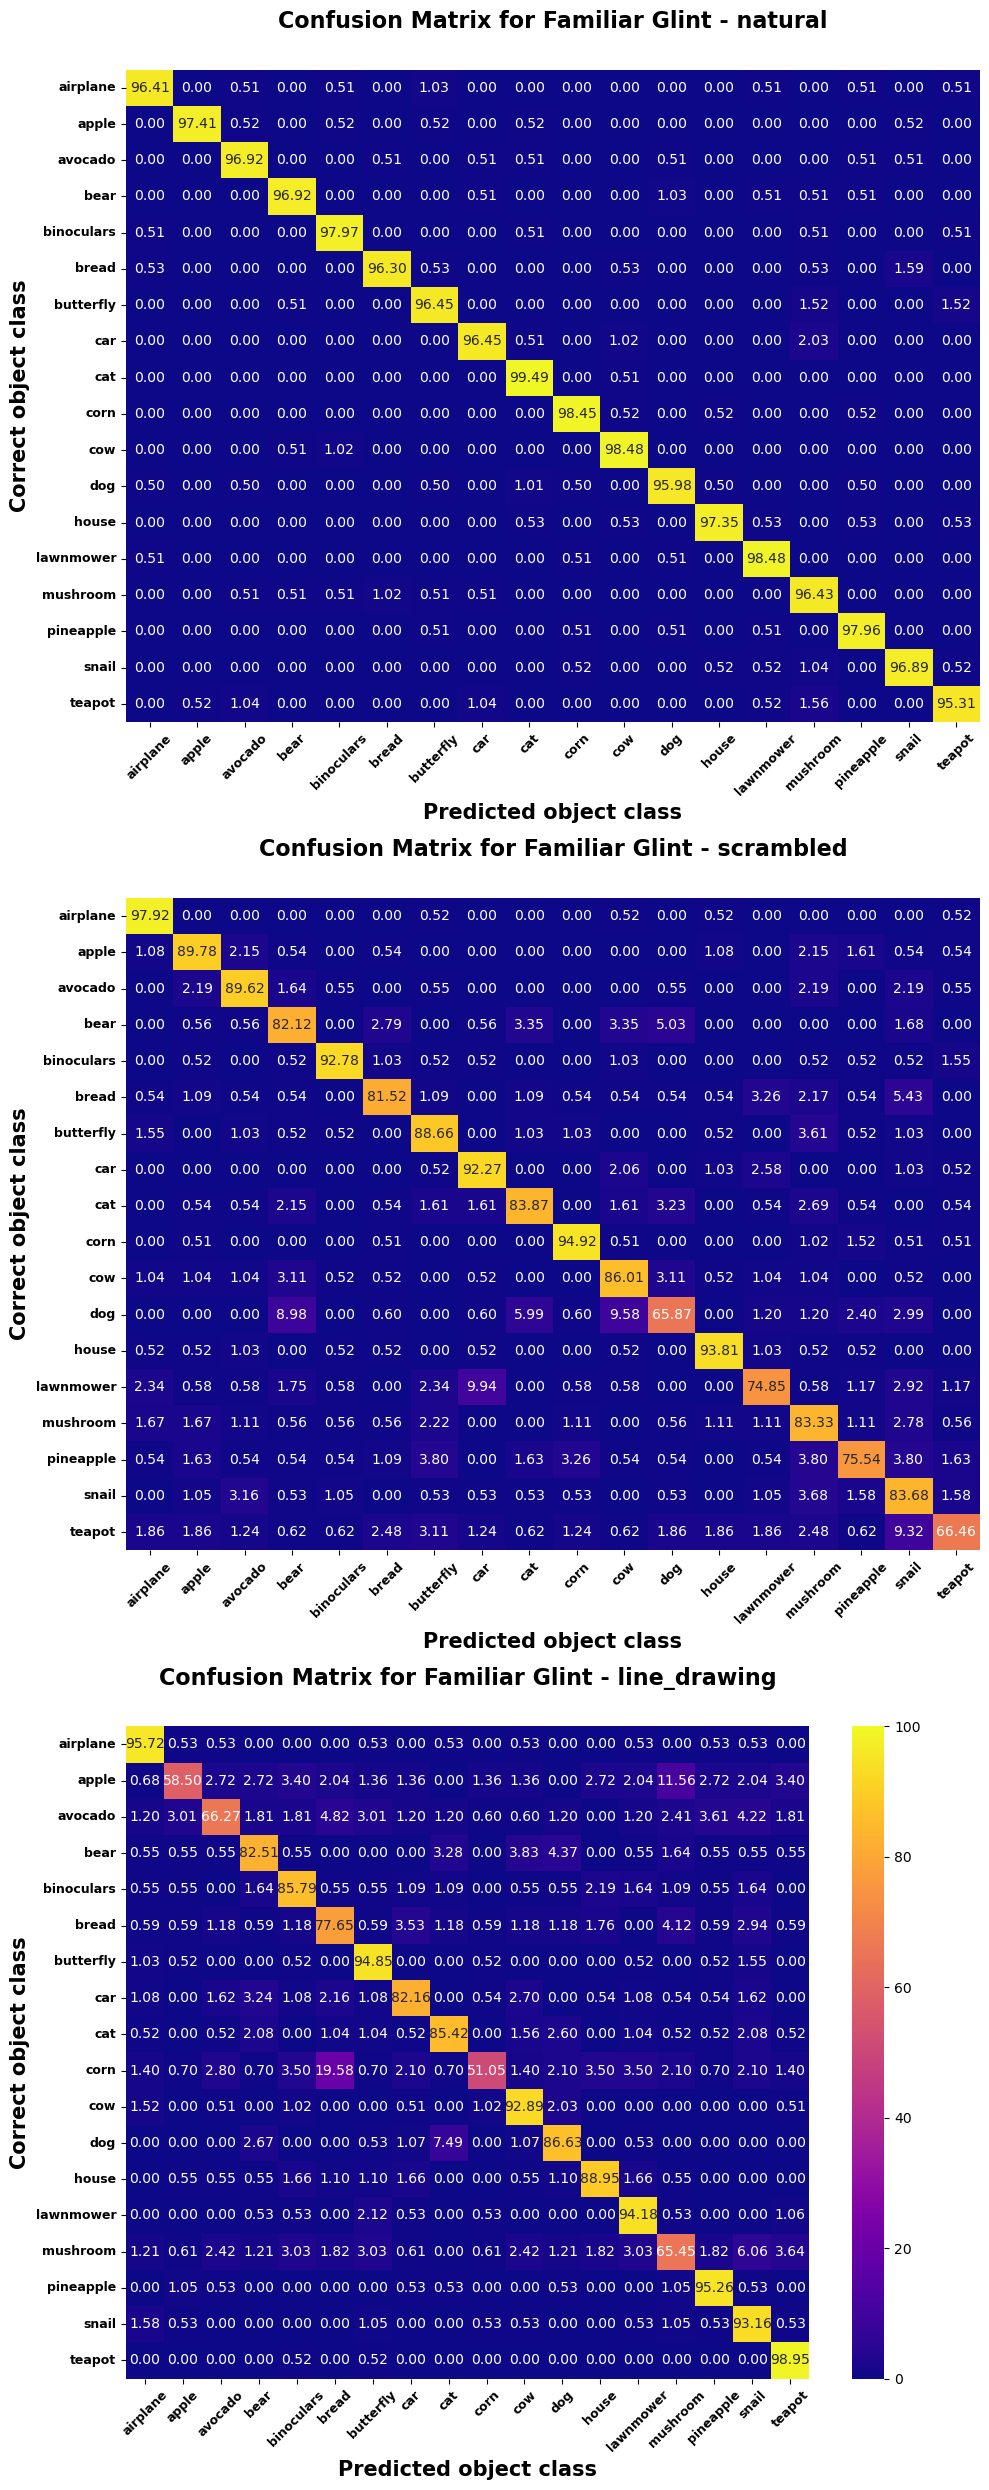

Experiment: Novel, Condition: natural
natural
response_by_subject    krar  sarangi  sistrum  sheng
correct_object_class                                
krar                  72.04     8.82     8.82  10.32
sarangi               15.88    67.60     4.94  11.59
sistrum               13.45     7.56    69.96   9.03
sheng                  5.51    10.81    11.86  71.82
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

Experiment: Novel, Condition: scrambled
scrambled
response_by_subject    krar  sarangi  sistrum  sheng
correct_object_class                                
krar                  34.38    20.00    24.79  20.83
sarangi               16.10    44.92    17.80  21.19
sistrum               17.72    14.56    50.63  17.09
sheng                 12.18    15.76    12.61  59.45
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

Experiment: Novel, Condition: line_dra

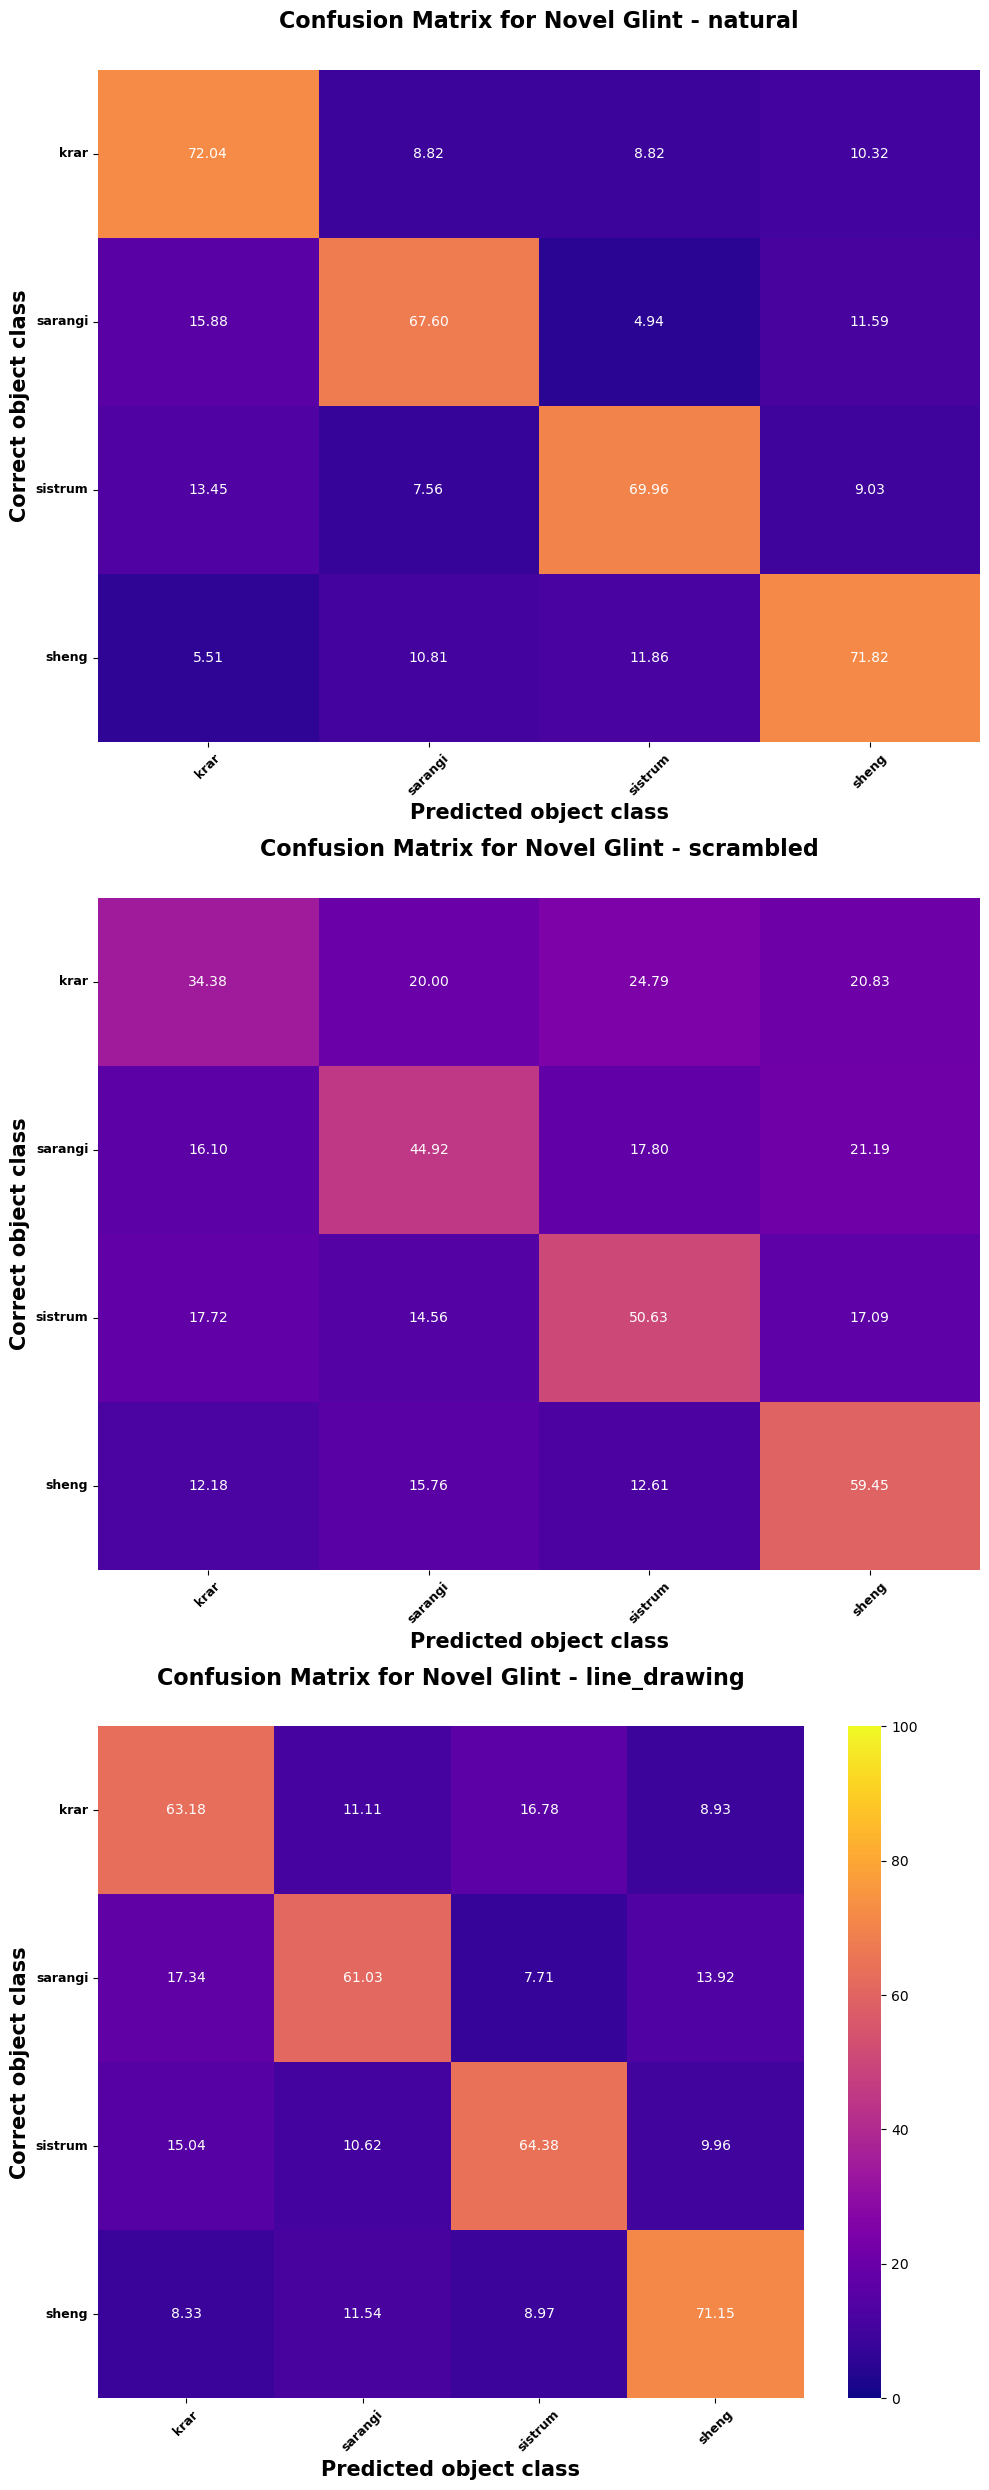

In [2]:
'''This function takes the summary dataframes we created for each experiment and produces confusion matrices for each condition within each experiment.

'''


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def create_confusion_matrices(familiar_sub_summary, novel_sub_summary, experiments):
    for experiment in experiments:
        if experiment == 'familiar':
            object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
        elif experiment == 'novel':
            object_classes = ['krar', 'sarangi', 'sistrum', 'sheng']

        conditions = ['natural', 'scrambled', 'line_drawing']

        for condition_name in conditions:
            if experiment == 'familiar':
                sub_summary = familiar_sub_summary
            elif experiment == 'novel':
                sub_summary = novel_sub_summary

            condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

            counts = pd.crosstab(
                condition_data['correct_object_class'],
                condition_data['response_by_subject'],
                
            )

            counts = counts.reindex(index=object_classes, columns=object_classes, fill_value=0)

            row_totals = counts.sum(axis=1)
            response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

            # Create the confusion matrices for each condition, and do this for both experiments (familiar and novel)
            if experiment == 'familiar': # Familiar experiment
                if condition_name == 'natural':
                    fam_confusion_matrix_natural = response_percent.round(2)
                
                elif condition_name == 'scrambled':
                    fam_confusion_matrix_scrambled = response_percent.round(2)

                elif condition_name == 'line_drawing':
                    fam_confusion_matrix_line_drawing = response_percent.round(2)
            elif experiment == 'novel': # Novel Experiment
                if condition_name == 'natural':
                    novel_confusion_matrix_natural = response_percent.round(2)
                
                elif condition_name == 'scrambled':
                    novel_confusion_matrix_scrambled = response_percent.round(2)

                elif condition_name == 'line_drawing':
                    novel_confusion_matrix_line_drawing = response_percent.round(2)

            print(f"Experiment: {experiment.capitalize()}, Condition: {condition_name}")
            print(condition_name)
            print(response_percent.round(2))
            print("Row sums:")
            print(response_percent.sum(axis=1).round(2))
            print()

        # Plot each confusion matrix to visualize the patterns of responses for each condition
        fig, axes = plt.subplots(3, 1, figsize=(10, 25), sharey=True)

        for ax, condition_name in zip(axes, conditions):
            condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

            counts = pd.crosstab(
                condition_data['correct_object_class'],
                condition_data['response_by_subject']
            )

            counts = counts.reindex(index=object_classes, columns=object_classes, fill_value=0)

            response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

            sns.heatmap(
                response_percent,
                ax=ax,
                cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
                vmin=0,
                vmax=100,
                annot=True,
                fmt='.2f',
                annot_kws={'fontsize':10},
                cbar=ax is axes[-1]
                
            )

            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, fontweight='bold')  # Rotate y-axis labels to horizontal
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=9, fontweight='bold')  # Rotate x-axis labels for better readability
            ax.set_title(f'Confusion Matrix for {experiment.capitalize()} Glint - {condition_name}', fontsize=16, fontweight='bold', pad=30)
            ax.set_xlabel('Predicted object class', fontsize=15, fontweight='bold')
            ax.set_ylabel('Correct object class', fontsize=15, fontweight='bold') 


        plt.tight_layout()
        plt.show()

    return fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing

fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing = create_confusion_matrices(familiar_sub_summary, novel_sub_summary, experiments)

### Function 3: compute_rsa_correlations

This only currently work on natural condition, or one at a time, it will be able to run all of the conditions in final form

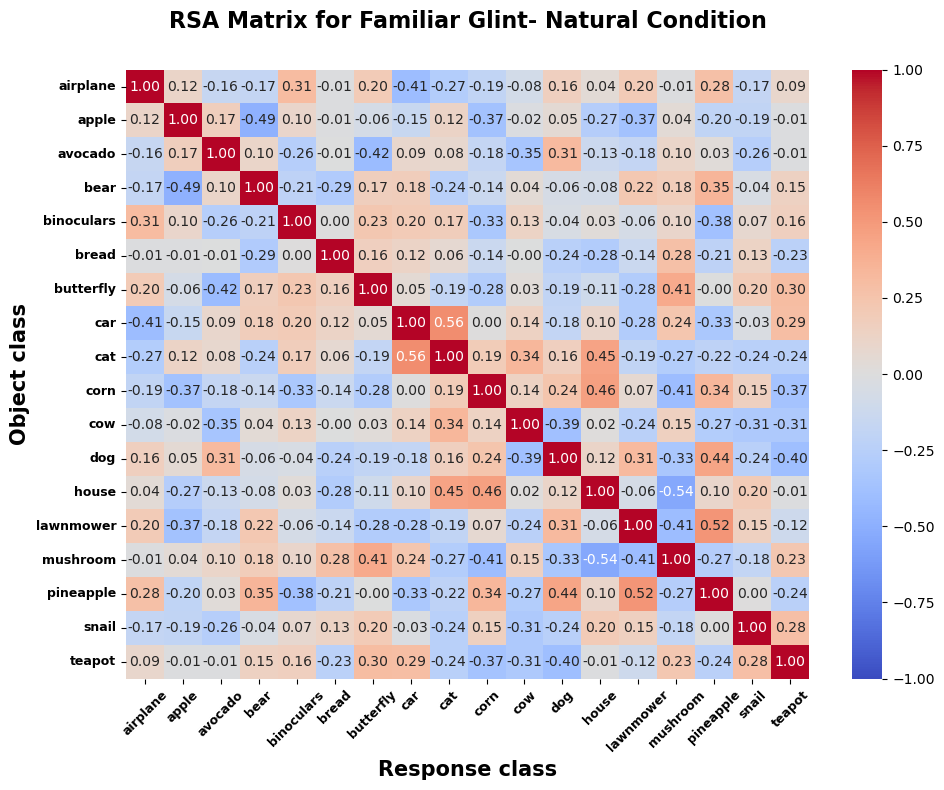

In [ ]:
# Now we need to perform the actual RSA analysis
from scipy.stats import spearmanr
confusion_matrix = fam_confusion_matrix_natural 
# Correlate each object class to each response class 
def compute_rsa_correlations(confusion_matrix, experiment):

# Initialize an empty list to store the correlation results
    correlation_results = []
    if experiment == 'familiar':
        object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

    elif experiment == 'novel':
        object_classes = ['krar', 'sarangi', 'sistrum', 'sheng']

    for obj in object_classes:

        # Get the row of the current object class in the natural condition confusion matrix
        natural_row = confusion_matrix.loc[obj].values

        # For this row, Perform pairwise Spearman correlation between the current object class and all other response classes within that same row (ex: column 1 vs column 2, column 1 vs column 3, etc.) and store the results in a list
        for other_obj in object_classes:
            other_row = confusion_matrix.loc[other_obj].values
            corr, _ = spearmanr(natural_row, other_row) # we don't care about the p-value here, just the correlation coefficient

            # Add the correlation result to the list as via a dictionary with the object class, the response class, and the correlation coefficient
            correlation_results.append({
                'object': obj,
                'response': other_obj,
                'correlation': 1 - corr # We subtract the correlation coefficient from 1 to get a dissimilarity measure
            })
    #Since we have the correlations for each object class with every other response class, we can create a new dataframe to store these results and then visualize them as an RSA matrix
    correlation_df = pd.DataFrame(correlation_results)

    # Now pivot the correlation dataframe to create a matrix format where the rows are the object classes, the columns are the response classes, and the values are the correlation coefficients
    rsa_matrix = correlation_df.pivot(index='object', columns='response', values='correlation')

    return correlation_results, rsa_matrix

def plot_rsa_matrix(rsa_matrix):
    #Let's plot this Data!!!!
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        rsa_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize':10}
    )
    plt.title('RSA Matrix for Familiar Glint- Natural Condition', fontsize=16, fontweight='bold', pad=30)
    plt.xlabel('Response class', fontsize=15, fontweight='bold')
    plt.ylabel('Object class', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, fontsize=9, fontweight='bold')
    plt.yticks(rotation=0, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()
    



correlation_results, rsa_matrix = compute_rsa_correlations(confusion_matrix = fam_confusion_matrix_natural, experiment = 'familiar')

plot_rsa_matrix(rsa_matrix)

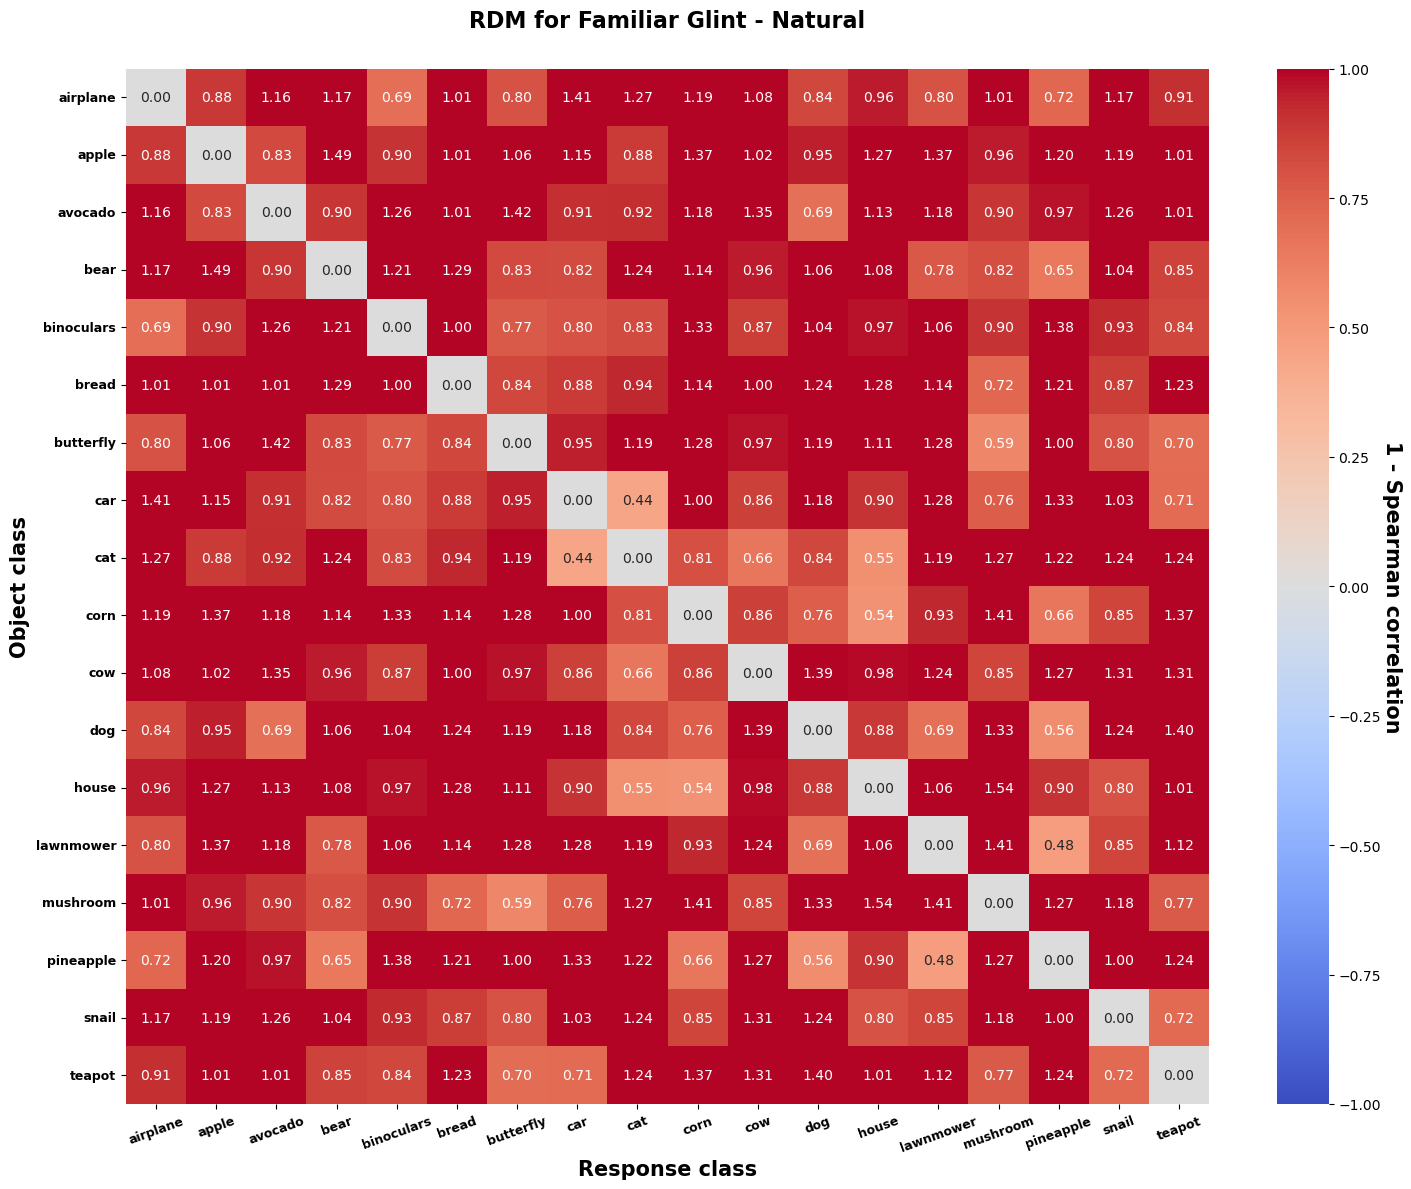

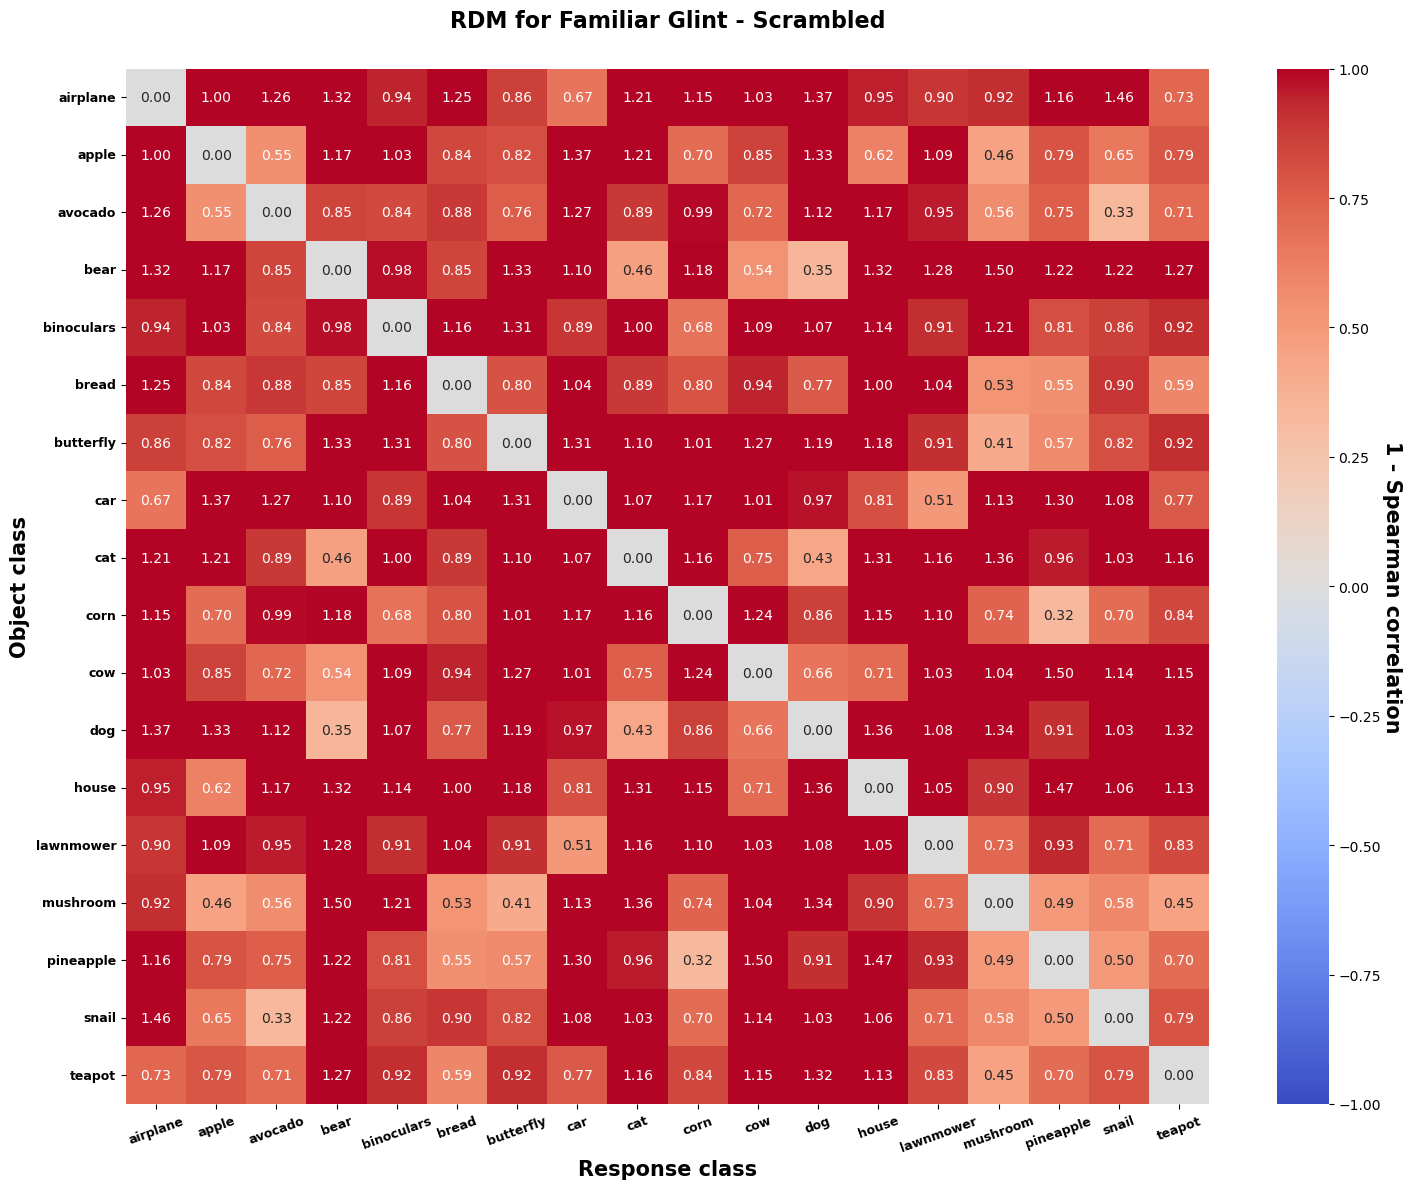

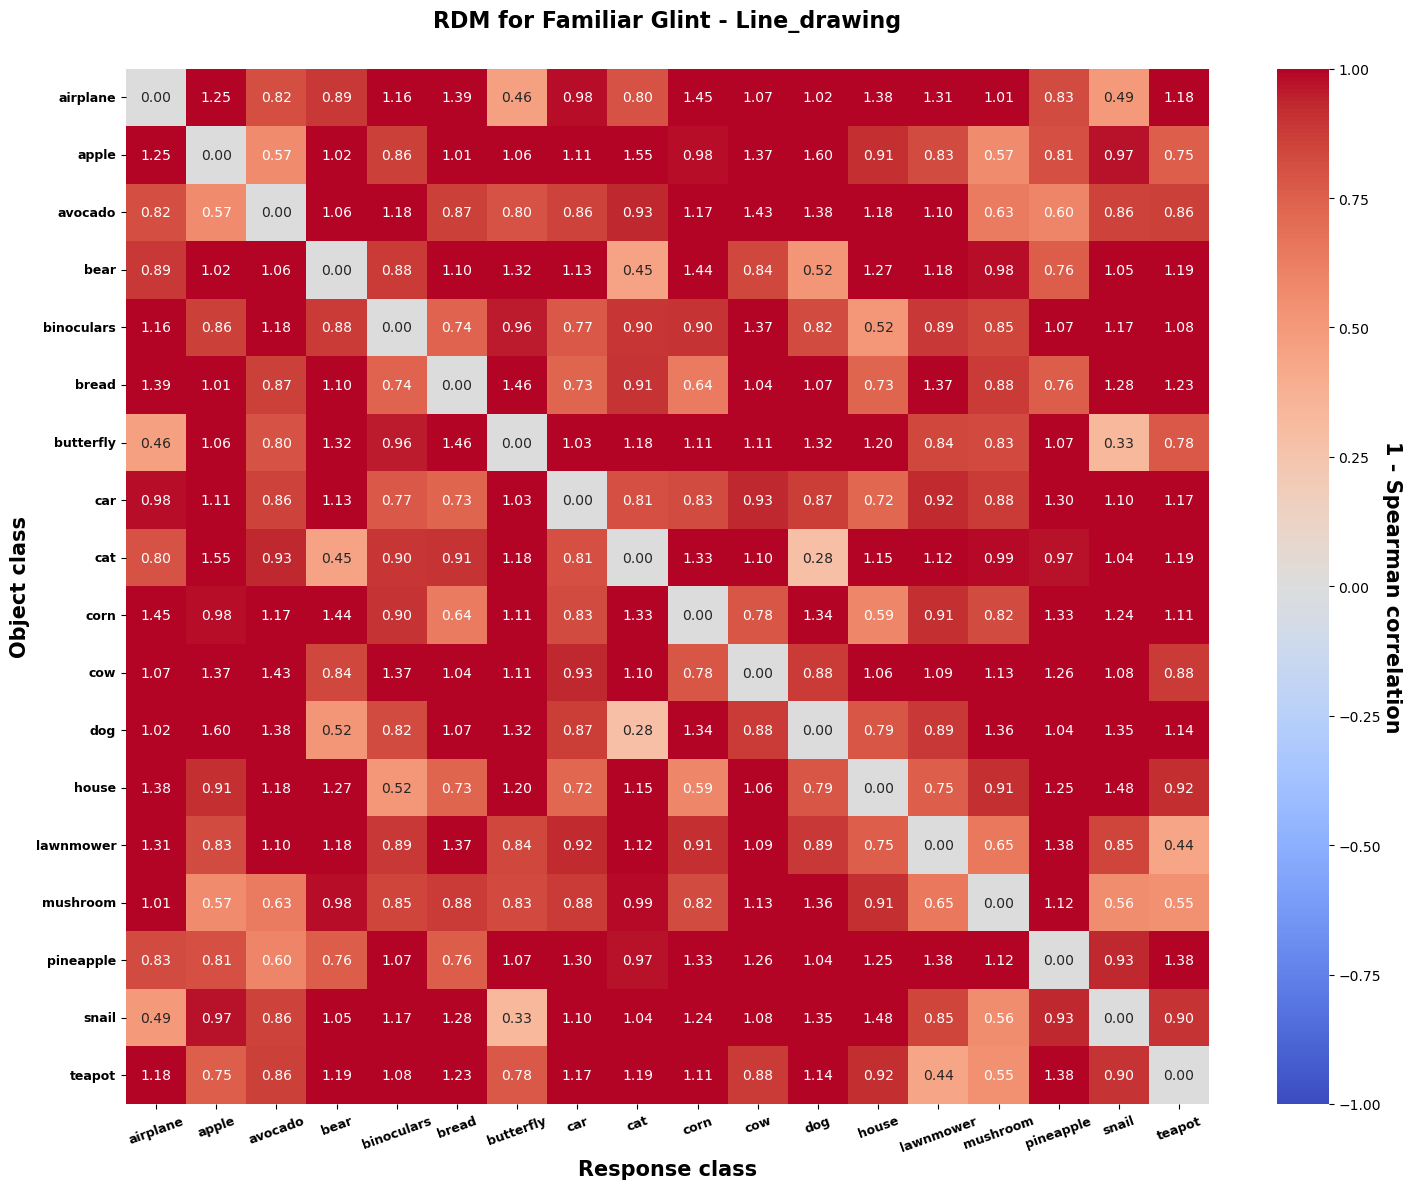

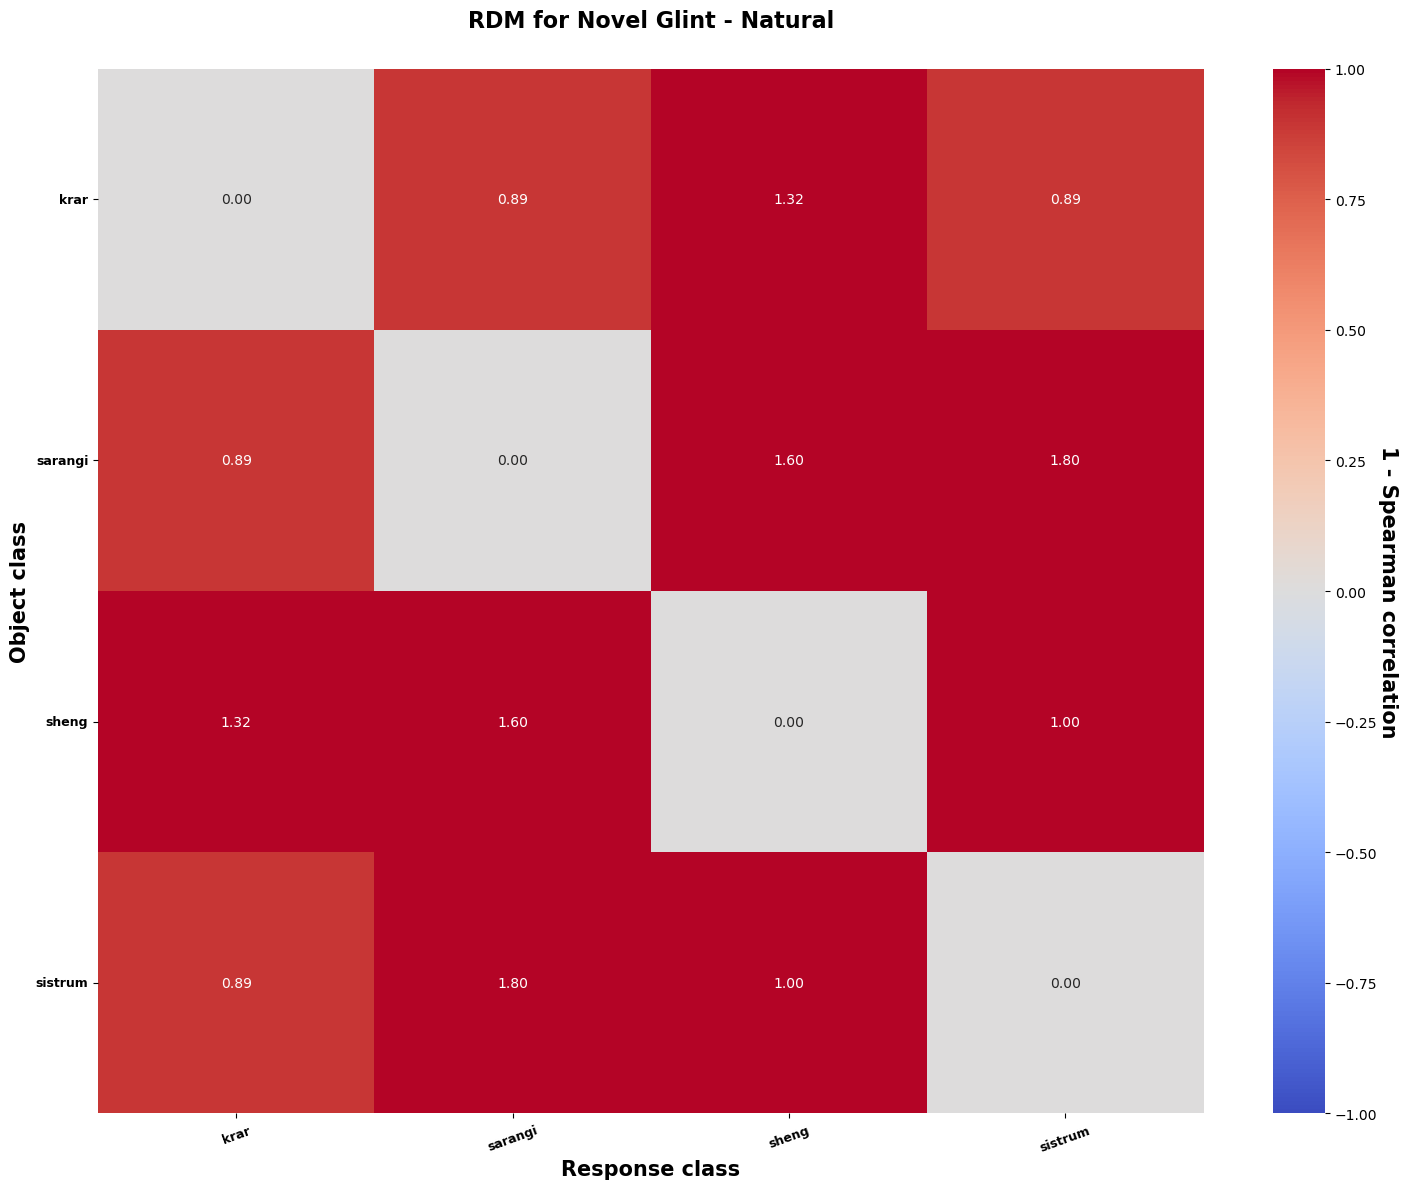

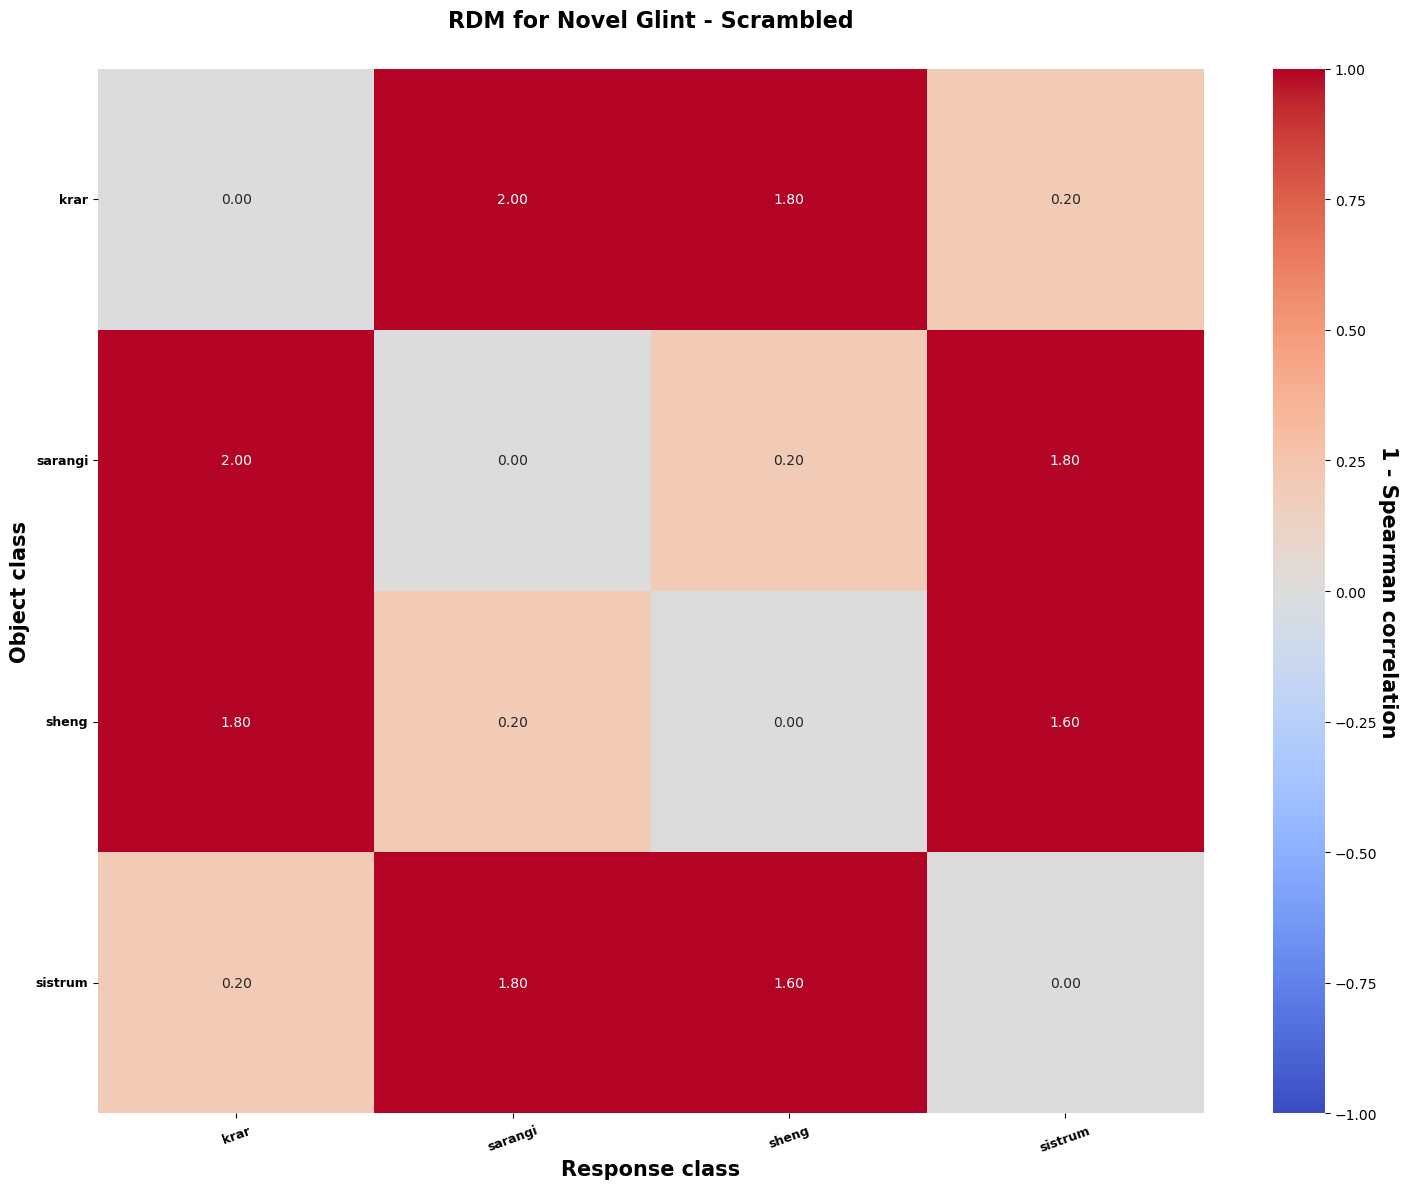

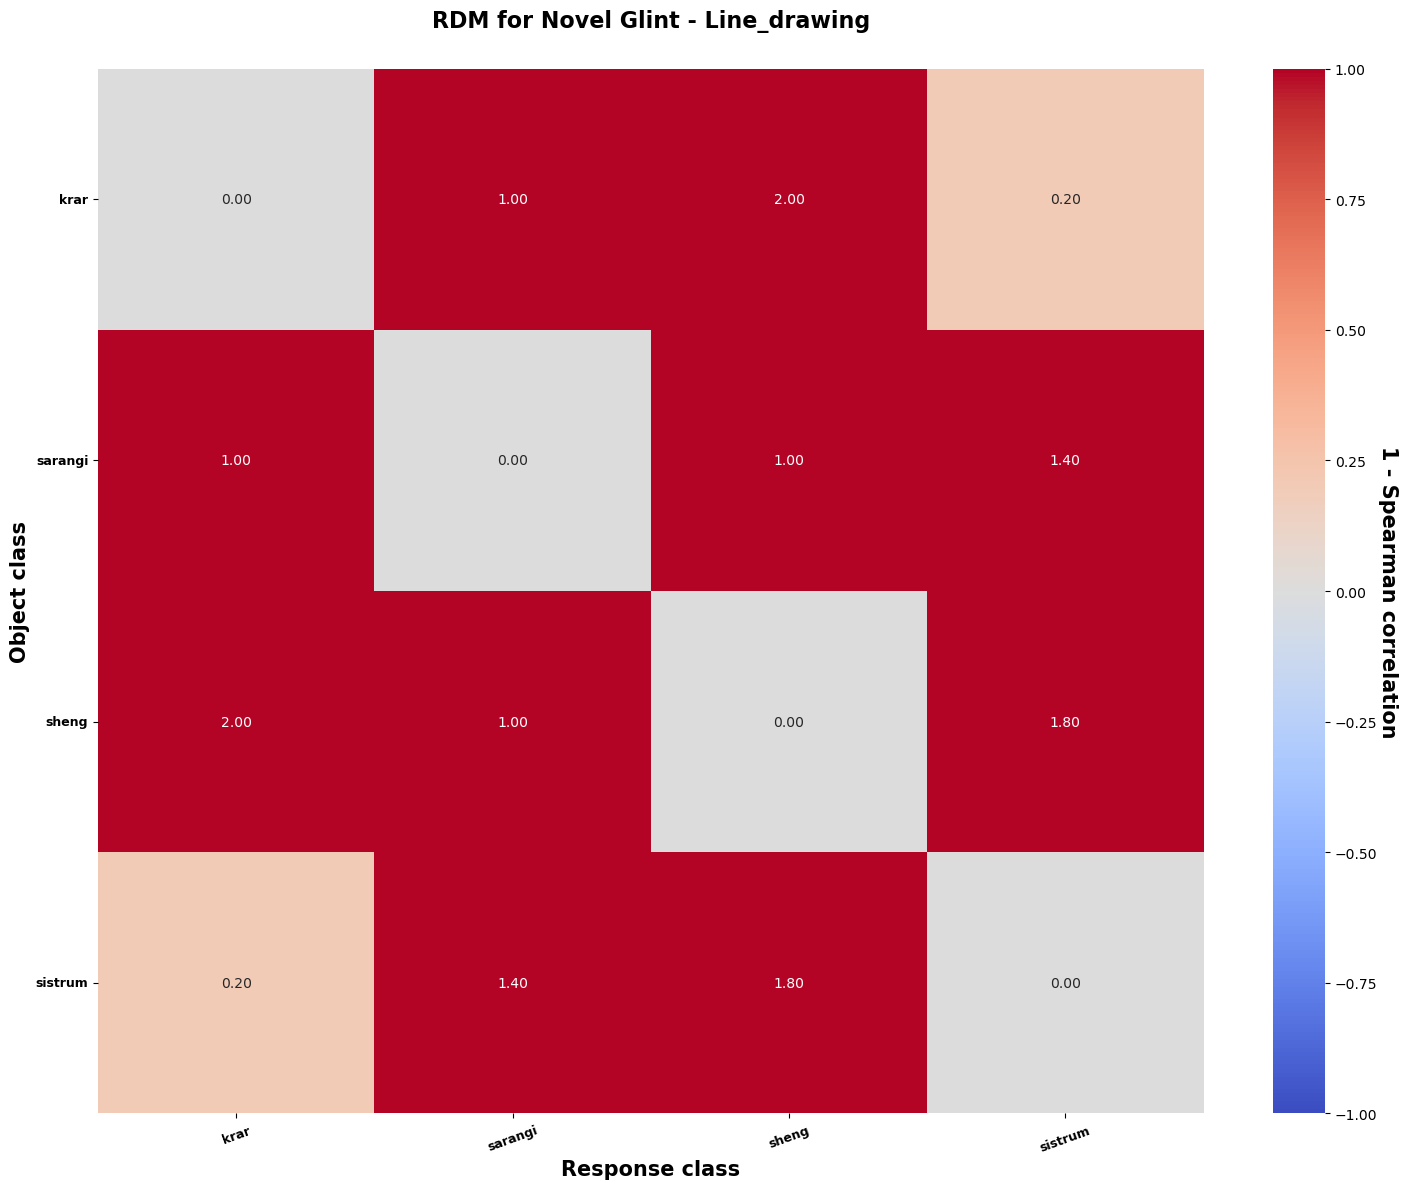

In [18]:
from scipy.stats import spearmanr

def plot_rsa_matrix(rsa_matrix, experiment, condition):
    #Let's plot this Data!!!!
    fig, ax = plt.subplots(figsize=(15, 12))
    sns.heatmap(
        rsa_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize':10},
        cbar = True,
    )
    # Add a label to the color bar
    cbar = ax.collections[0].colorbar
    cbar.set_label('1 - Spearman correlation', rotation=270, labelpad=15, fontsize=15, fontweight='bold')  # rotation=270 makes it vertical
    plt.title(f'RDM for {experiment.capitalize()} Glint - {condition.capitalize()}', fontsize=16, fontweight='bold', pad=30)
    plt.xlabel('Response class', fontsize=15, fontweight='bold')
    plt.ylabel('Object class', fontsize=15, fontweight='bold')
    plt.xticks(rotation=20, fontsize=9, fontweight='bold')
    plt.yticks(rotation=0, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

experiments = ['familiar', 'novel'] # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes
conditions = ['natural', 'scrambled', 'line_drawing']

# Correlate each object class to each response class 
def compute_rsa_correlations(confusion_matrix, experiment, conditions):
    for experiment in experiments:

        for condition in conditions:
            if condition == 'natural' and experiment == 'familiar':
                confusion_matrix = fam_confusion_matrix_natural
            elif condition == 'scrambled' and experiment == 'familiar':
                confusion_matrix = fam_confusion_matrix_scrambled
            elif condition == 'line_drawing' and experiment == 'familiar':
                confusion_matrix = fam_confusion_matrix_line_drawing
            elif condition == 'natural' and experiment == 'novel':
                confusion_matrix = novel_confusion_matrix_natural
            elif condition == 'scrambled' and experiment == 'novel':
                confusion_matrix = novel_confusion_matrix_scrambled
            elif condition == 'line_drawing' and experiment == 'novel':
                confusion_matrix = novel_confusion_matrix_line_drawing

        # Initialize an empty list to store the correlation results
            correlation_results = []
            if experiment == 'familiar':
                object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

            elif experiment == 'novel':
                object_classes = ['krar', 'sarangi', 'sistrum', 'sheng']

            for obj in object_classes:

                # Get the row of the current object class in the natural condition confusion matrix
                current_obj_row = confusion_matrix.loc[obj].values

                # For this row, Perform pairwise Spearman correlation between the current object class and all other response classes within that same row (ex: column 1 vs column 2, column 1 vs column 3, etc.) and store the results in a list
                for other_obj in object_classes:
                    other_row = confusion_matrix.loc[other_obj].values
                    corr, _ = spearmanr(current_obj_row, other_row) # we don't care about the p-value here, just the correlation coefficient

                    # Add the correlation result to the list as via a dictionary with the object class, the response class, and the correlation coefficient
                    correlation_results.append({
                        'object': obj,
                        'response': other_obj,
                        'correlation': 1 - corr # We subtract the correlation coefficient from 1 to get a dissimilarity measure
                    })
            #Since we have the correlations for each object class with every other response class, we can create a new dataframe to store these results and then visualize them as an RSA matrix
            correlation_df = pd.DataFrame(correlation_results)
            


            # Now pivot the correlation dataframe to create a matrix format where the rows are the object classes, the columns are the response classes, and the values are the correlation coefficients
            rsa_matrix = correlation_df.pivot(index='object', columns='response', values='correlation')

            if condition == 'natural' and experiment == 'familiar':
                fam_rsa_matrix_natural = rsa_matrix
                fam_correlation_df_natural = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)
            elif condition == 'scrambled' and experiment == 'familiar':
                fam_rsa_matrix_scrambled = rsa_matrix
                fam_correlation_df_scrambled = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)
            elif condition == 'line_drawing' and experiment == 'familiar':
                fam_rsa_matrix_line_drawing = rsa_matrix
                fam_correlation_df_line_drawing = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)
            elif condition == 'natural' and experiment == 'novel':
                novel_rsa_matrix_natural = rsa_matrix
                novel_correlation_df_natural = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)
            elif condition == 'scrambled' and experiment == 'novel':
                novel_rsa_matrix_scrambled = rsa_matrix
                novel_correlation_df_scrambled = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)
            elif condition == 'line_drawing' and experiment == 'novel':
                novel_rsa_matrix_line_drawing = rsa_matrix
                novel_correlation_df_line_drawing = correlation_df
                plot_rsa_matrix(rsa_matrix, experiment, condition)

    return fam_correlation_df_natural, fam_correlation_df_scrambled, fam_correlation_df_line_drawing, novel_correlation_df_natural, novel_correlation_df_scrambled, novel_correlation_df_line_drawing, fam_rsa_matrix_natural, fam_rsa_matrix_scrambled, fam_rsa_matrix_line_drawing, novel_rsa_matrix_natural, novel_rsa_matrix_scrambled, novel_rsa_matrix_line_drawing

fam_correlation_df_natural, fam_correlation_df_scrambled, fam_correlation_df_line_drawing, novel_correlation_df_natural, novel_correlation_df_scrambled, novel_correlation_df_line_drawing, fam_rsa_matrix_natural, fam_rsa_matrix_scrambled, fam_rsa_matrix_line_drawing, novel_rsa_matrix_natural, novel_rsa_matrix_scrambled, novel_rsa_matrix_line_drawing = compute_rsa_correlations(confusion_matrix = fam_confusion_matrix_natural, experiment = 'familiar', conditions = conditions)

### Function 4: condition_dissimilarity

Here we will now calculate the similarity between the response patterns of each condition to eachother. For example, we want to know for the familiar, and novel experiments, how similar the pattern of repsonses in the natural condition are to the pattern of responses in the scrambled and line_drawing conditions. 

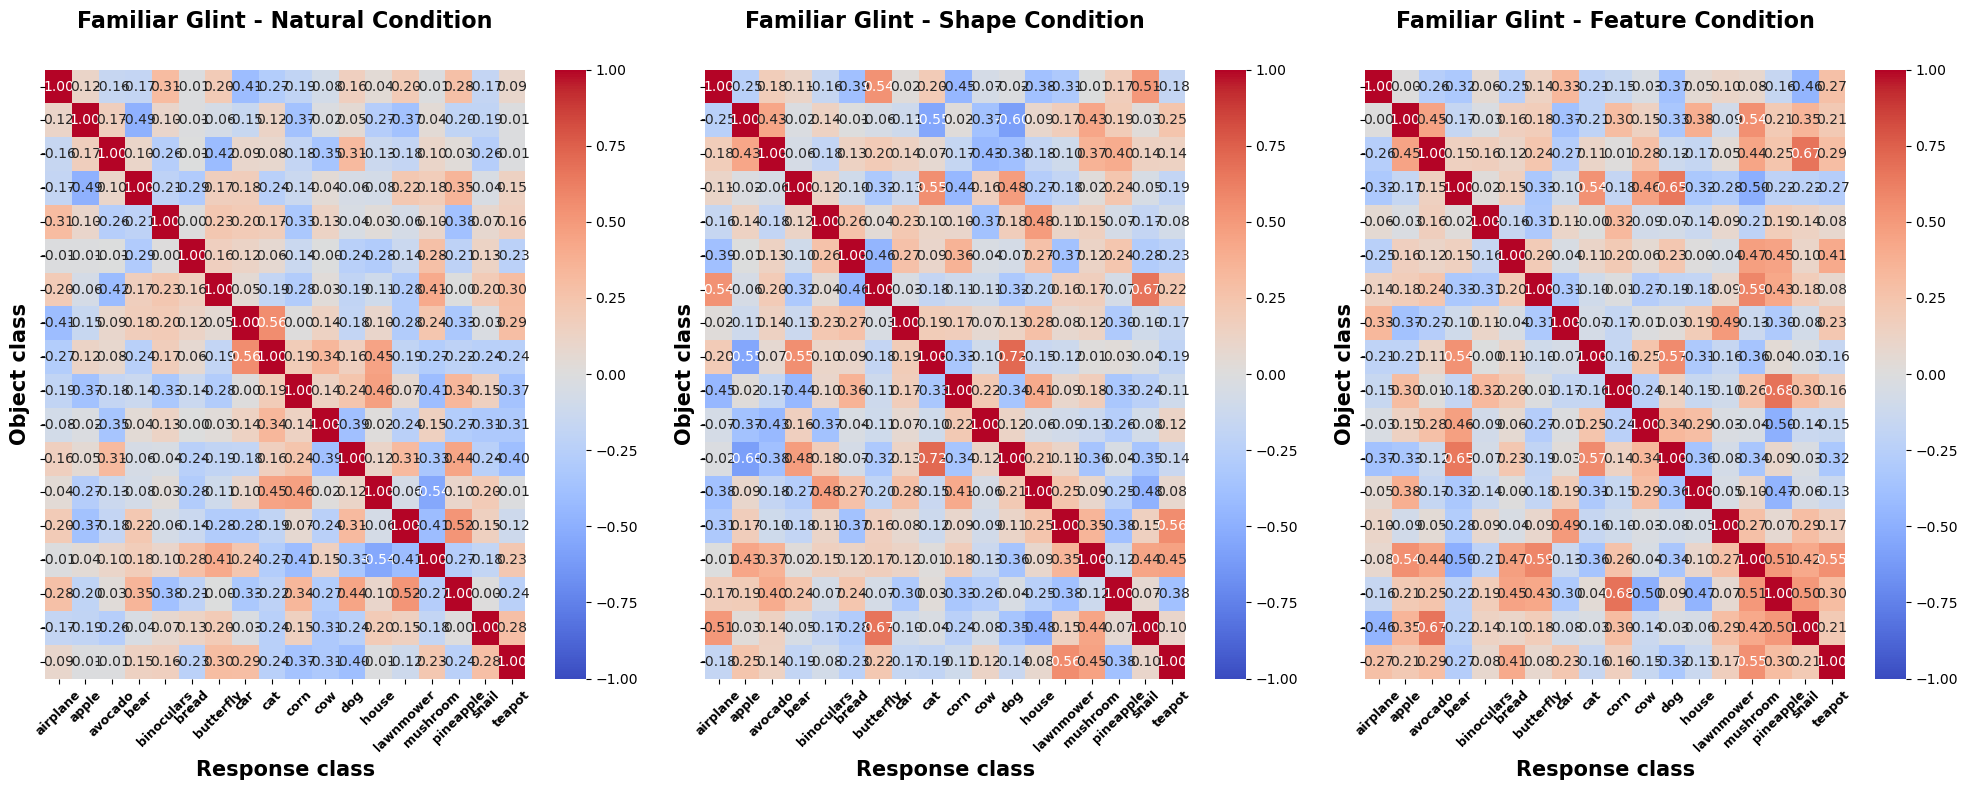

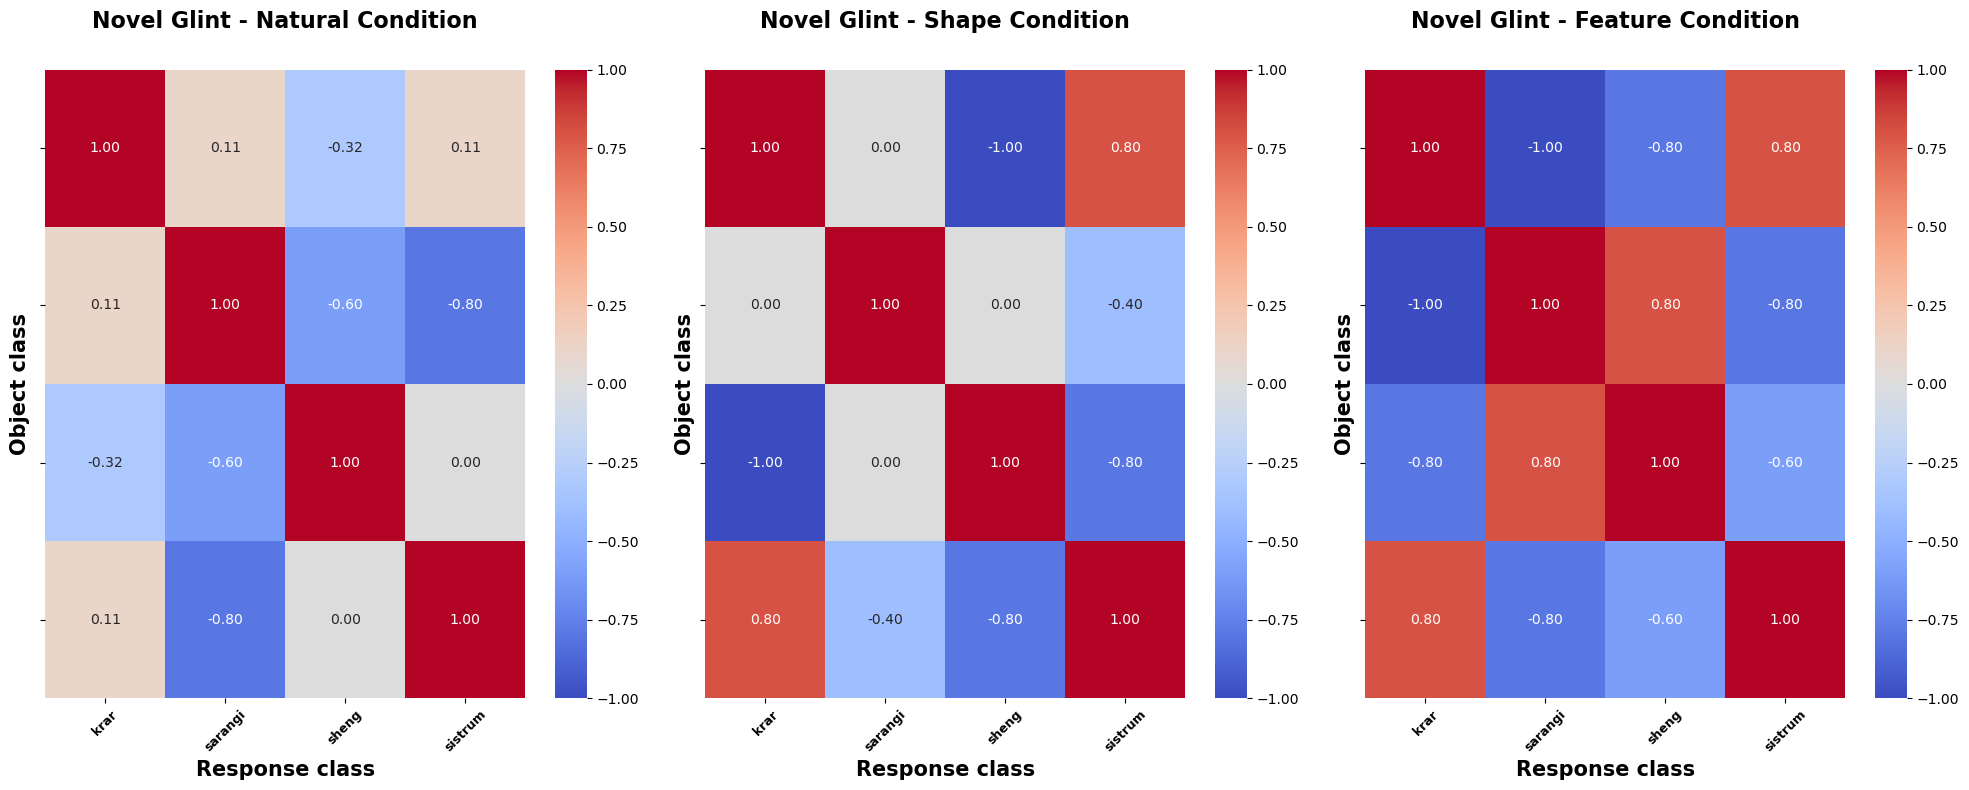

In [16]:
# Combine all conditions into one dataframe for familiar and one dataframe for novel, and then save these dataframes as csv files so we can use them for further analysis and visualization in R if we want to
familiar_comparison_df = (
    fam_correlation_df_natural.rename(columns={'correlation':'natural'})
    .merge(fam_correlation_df_line_drawing.rename(columns={'correlation':'shape'}),
        on=['object','response'])
        
    .merge(
        fam_correlation_df_scrambled.rename(columns={'correlation':'feature'}),
        on=['object','response']
    )
)
novel_comparison_df = (
    novel_correlation_df_natural.rename(columns={'correlation':'natural'})
    .merge(novel_correlation_df_line_drawing.rename(columns={'correlation':'shape'}),
        on=['object','response'])
        
    .merge(
        novel_correlation_df_scrambled.rename(columns={'correlation':'feature'}),
        on=['object','response']
    )
)

# plot the comparison as heatmaps to visualize the differences in the correlation patterns across conditions within each experiment
def plot_comparison_heatmap(comparison_df, experiment):
    comparison_matrix = comparison_df.pivot(index='object', columns='response', values=['natural', 'shape', 'feature'])
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

    for ax, condition in zip(axes, ['natural', 'shape', 'feature']):
        sns.heatmap(
            comparison_matrix[condition],
            ax=ax,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            annot=True,
            fmt='.2f',
            annot_kws={'fontsize':10}
        )
        ax.set_title(f'{experiment.capitalize()} Glint - {condition.capitalize()} Condition', fontsize=16, fontweight='bold', pad=30)
        ax.set_xlabel('Response class', fontsize=15, fontweight='bold')
        ax.set_ylabel('Object class', fontsize=15, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=9, fontweight='bold')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_comparison_heatmap(familiar_comparison_df, experiment = 'familiar')
plot_comparison_heatmap(novel_comparison_df, experiment = 'novel')


In [ ]:
object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

# filter the all the rows wherin the object 

In [ ]:

natural_corr = fam_correlation_df_natural.groupby('object').get_group('airplane')
scrambled_corr = fam_correlation_df_scrambled.groupby('object').get_group('airplane')

summary_df = pd.DataFrame(columns=['object', 'response', 'natural_corr', 'scrambled_corr', 'corr_diff'])
for i in range(0, 18):
    print(scrambled_corr.iloc[i])
    print(natural_corr.iloc[i])

    

    corr_diff, _ = spearmanr(scrambled_corr['correlation'][i], natural_corr['correlation'][i])

    # Add to a list or dataframe to store the differences for further analysis if needed
    summary_df = pd.concat([summary_df, pd.DataFrame({
        'object': [natural_corr.iloc[i]['object']],
        'response': [natural_corr.iloc[i]['response']],
        'natural_corr': [natural_corr.iloc[i]['correlation']],
        'scrambled_corr': [scrambled_corr.iloc[i]['correlation']],
        'corr_diff': [corr_diff]
    })], ignore_index=True)

    print(f"Difference in correlation for object {natural_corr.iloc[i]['response']}: {corr_diff:.4f}")
    print()

object         airplane
response       airplane
correlation         1.0
Name: 0, dtype: object
object         airplane
response       airplane
correlation         1.0
Name: 0, dtype: object
Difference in correlation for object airplane: nan

object         airplane
response          apple
correlation    0.004163
Name: 1, dtype: object
object         airplane
response          apple
correlation     0.11651
Name: 1, dtype: object
Difference in correlation for object apple: nan

object         airplane
response        avocado
correlation   -0.261045
Name: 2, dtype: object
object         airplane
response        avocado
correlation   -0.156627
Name: 2, dtype: object
Difference in correlation for object avocado: nan

object         airplane
response           bear
correlation   -0.319623
Name: 3, dtype: object
object         airplane
response           bear
correlation   -0.174176
Name: 3, dtype: object
Difference in correlation for object bear: nan

object           airplane
response      

In [54]:



ral_corr = familiar_comparison_df[(familiar_comparison_df['object'] == 'airplane') & (familiar_comparison_df['response'] == 'apple')]['natural'].values
comparisons = [(obj, response) for obj in familiar_comparison_df['object'].unique() for response in familiar_comparison_df['response'].unique()]
summary_correlation_df = pd.DataFrame(columns=['Comparison', 'Natural-Shape', 'Natural-Feature', 'Shape-Feature'])

# grab the row with the object class and response class you want to look at, and then pull the correlation value for the natural condition 
for object in object_classes:

    # grab all the rows in the familiar comparison dataframe that correspond to the current object class,
    natural_corr = familiar_comparison_df.groupby('object' == object)['natural']
    shape_corr = familiar_comparison_df.groupby(['object', 'response']).get_group((object, object))['shape'].values[0]
    feature_corr = familiar_comparison_df.groupby(['object', 'response']).get_group((object, object))['feature'].values[0]


    for response in object_classes:
        comparison = (object, response)
        
        natural_corr = familiar_comparison_df.groupby(['object', 'response']).get_group(comparison)['natural'].values[0]
        shape_corr = familiar_comparison_df.groupby(['object', 'response']).get_group(comparison)['shape'].values[0]
        feature_corr = familiar_comparison_df.groupby(['object', 'response']).get_group(comparison)['feature'].values[0]

        # correlate the correlations across conditions to see if there is a relationship between the correlation patterns in the natural condition and the shape and feature conditions, and then print out the results for each comparison
        natural_shape_corr, _ = spearmanr(natural_corr, shape_corr)
        natural_feature_corr, _ = spearmanr(natural_corr, feature_corr)
        shape_feature_corr, _ = spearmanr(shape_corr, feature_corr)

    # add the correlation results to a new dataframe to summarize the relationships between the conditions across all comparisons
    correlation_results = pd.DataFrame({
        'Comparison': [comparison],
        'Natural-Shape': [natural_shape_corr],
        'Natural-Feature': [natural_feature_corr],
        'Shape-Feature': [shape_feature_corr]
    })

    # append the correlation results to a summary dataframe that will store the results for all comparisons
    summary_correlation_df = pd.concat([summary_correlation_df, correlation_results], ignore_index=True)

    print(f"Comparison: {comparison}, Correlation in natural condition: {natural_corr}")
    print(f"Comparison: {comparison}, Correlation in shape condition: {shape_corr}")
    print(f"Comparison: {comparison}, Correlation in feature condition: {feature_corr}")



KeyError: False

In [39]:
# define all comparisions (e.g., airplane vs airplane, airplane vs car, etc.) for the natural condition in the familiar experiment, and then we can do this for all conditions and both experiments to compare the patterns of correlations across conditions and experiments
comparisons = [(obj, response) for obj in familiar_comparison_df['object'].unique() for response in familiar_comparison_df['response'].unique()]
natural_shape_corr = []
natural_feature_corr = []

for obj, response in tuple(comparisons):

    # get the correlation values for the current object class in the natural condition and the shape and feature conditions, for both familiar and novel experiments, so that we can correlate these values across conditions to see how similar the patterns of correlations are across conditions for each object class
    # We want to correlate the correlation patterns for each object class in the natural condition with the correlation patterns for that same object class in the shape and feature conditions, to see how similar the patterns of correlations are across these conditions for each object class. We can do this for both familiar and novel
    natural_corr = familiar_comparison_df[(familiar_comparison_df['object'] == obj) & (familiar_comparison_df['response'] == response)]['natural'].values
    shape_corr = familiar_comparison_df[(familiar_comparison_df['object'] == obj) & (familiar_comparison_df['response'] == response)]['shape'].values
    feature_corr = familiar_comparison_df[(familiar_comparison_df['object'] == obj) & (familiar_comparison_df['response'] == response)]['feature'].values

    # correlate the correlation patterns for each object class in the natural condition with the correlation patterns for that same object class in the shape and feature conditions, to see how similar the patterns of correlations are across these conditions for each object class. We can do this for both familiar and novel experiments and then compare the results across experiments to see if there are differences in how similar the correlation patterns are across conditions for familiar vs novel objects.
    # Correlate natural and shape conditions
    corr_ns, _ = spearmanr(natural_corr, shape_corr)
    natural_shape_corr.append({'object': obj, 'correlation': corr_ns})

    # Correlate natural and feature conditions
    corr_nf, _ = spearmanr(natural_corr, feature_corr)
    natural_feature_corr.append({'object': obj, 'correlation': corr_nf})

# Create dataframes to store the results of these comparisons
natural_shape_comparison_df = pd.DataFrame(natural_shape_corr)
natural_feature_comparison_df = pd.DataFrame(natural_feature_corr)


In [ ]:
# with the combined dataframes for familiar and novel, we can now perform statistical tests to compare the correlation patterns across conditions within each experiment. For example, we can use paired t-tests or ANOVA to see if there are significant differences in the correlation coefficients between the natural, shape, and feature conditions.

# for now lets just correlate the correlation coefficients between the natural and shape conditions, and between the natural and feature conditions, for both familiar and novel experiments. This will give us a sense of how similar the correlation patterns are across these conditions.
# We will compare the object-wise correlation coefficients between the natural and shape conditions, and between the natural and feature conditions, for both familiar and novel experiments. This will give us a sense of how similar the correlation patterns are across these conditions.

object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

# take the object in each row and correlate the correlation coefficients between the natural and shape conditions, and between the natural and feature conditions, for both familiar and novel experiments. This will give us a sense of how similar the correlation patterns are across these conditions.
def correlate_conditions(comparison_df, experiment):
    natural_shape_corr = []
    natural_feature_corr = []

    for obj in object_classes and obj in comparison_df['response'].unique():
        if experiment == 'familiar':
            comparison_df = familiar_comparison_df
        elif experiment == 'novel':            
            comparison_df = novel_comparison_df

        natural_corr = comparison_df[comparison_df['object'] == obj]['natural'].values
        shape_corr = comparison_df[comparison_df['object'] == obj]['shape'].values
        feature_corr = comparison_df[comparison_df['object'] == obj]['feature'].values

        # Correlate natural and shape conditions
        corr_ns, _ = spearmanr(natural_corr, shape_corr)
        natural_shape_corr.append({'object': obj, 'correlation': corr_ns})

        # Correlate natural and feature conditions
        corr_nf, _ = spearmanr(natural_corr, feature_corr)
        natural_feature_corr.append({'object': obj, 'correlation': corr_nf})

    natural_shape_df = pd.DataFrame(natural_shape_corr)
    natural_feature_df = pd.DataFrame(natural_feature_corr)

    return natural_shape_df, natural_feature_df

natural_shape_df_familiar, natural_feature_df_familiar = correlate_conditions(familiar_comparison_df, experiment = 'familiar')
natural_shape_df_novel, natural_feature_df_novel = correlate_conditions(novel_comparison_df, experiment = 'novel')

# plot the correlation coefficients for each object class between the natural and shape conditions, and between the natural and feature conditions, for both familiar and novel experiments. This will give us a sense of how similar the correlation patterns are across these conditions.
def plot_condition_correlations(natural_shape_df, natural_feature_df, experiment):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

    if experiment == 'familiar':
        natural_shape_df = natural_shape_df_familiar
        natural_feature_df = natural_feature_df_familiar
    elif experiment == 'novel':
        natural_shape_df = natural_shape_df_novel
        natural_feature_df = natural_feature_df_novel

    sns.heatmap(
        natural_shape_df.pivot(index='object', columns='correlation'),
        ax=axes[0],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize':10}
    )
    
    axes[0].set_title(f'{experiment.capitalize()} Glint - Natural vs Shape Condition', fontsize=16, fontweight='bold', pad=30)
    axes[0].set_xlabel('Object class', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Spearman Correlation', fontsize=15, fontweight='bold')

    sns.heatmap(
        natural_feature_df.pivot(index='object', columns='correlation'),
        ax=axes[1],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize':10}
    )
    axes[1].set_title(f'{experiment.capitalize()} Glint - Natural vs Feature Condition', fontsize=16, fontweight='bold', pad=30)
    axes[1].set_xlabel('Object class', fontsize=15, fontweight='bold')
    axes[1].set_ylabel('Spearman Correlation', fontsize=15, fontweight='bold')


    plt.tight_layout()
    plt.show()

plot_condition_correlations(natural_shape_df_familiar, natural_feature_df_familiar, experiment = 'familiar')



UnboundLocalError: local variable 'obj' referenced before assignment

/home/tuu89558@tu.temple.edu/.conda/envs/glint/lib/python3.8/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/tuu89558@tu.temple.edu/.conda/envs/glint/lib/python3.8/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


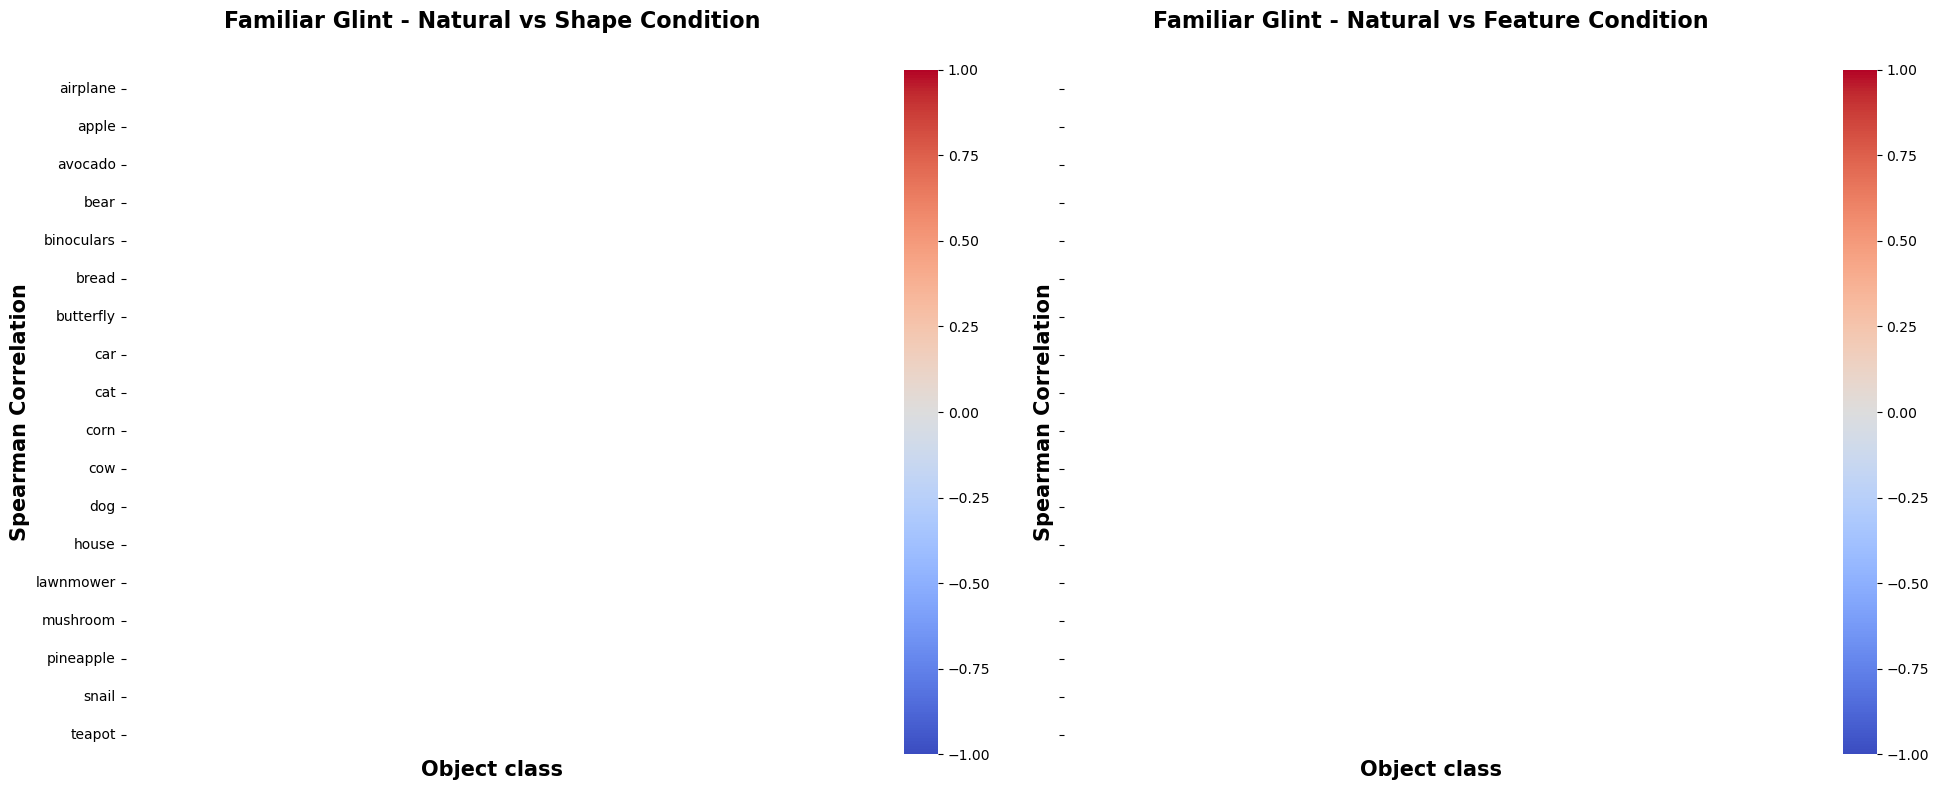

In [30]:
experiment = 'familiar'
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

if experiment == 'familiar':
    natural_shape_df = natural_shape_df_familiar
    natural_feature_df = natural_feature_df_familiar
elif experiment == 'novel':
    natural_shape_df = natural_shape_df_novel
    natural_feature_df = natural_feature_df_novel

sns.heatmap(
    natural_shape_df.pivot(index='object', columns='correlation'),
    ax=axes[0],
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'fontsize':10}
)

axes[0].set_title(f'{experiment.capitalize()} Glint - Natural vs Shape Condition', fontsize=16, fontweight='bold', pad=30)
axes[0].set_xlabel('Object class', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Spearman Correlation', fontsize=15, fontweight='bold')

sns.heatmap(
    natural_feature_df.pivot(index='object', columns='correlation'),
    ax=axes[1],
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'fontsize':10}
)
axes[1].set_title(f'{experiment.capitalize()} Glint - Natural vs Feature Condition', fontsize=16, fontweight='bold', pad=30)
axes[1].set_xlabel('Object class', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Spearman Correlation', fontsize=15, fontweight='bold')


plt.tight_layout()
plt.show()

### Novel Confusion Matrix

In [12]:
import pandas as pd
import numpy as np


novel_objects = ['krar', 'sarangi', 'sistrum', 'sheng']

conditions = ['natural', 'scrambled', 'line_drawing']

for condition_name in conditions:
    condition_data = sub_summary[sub_summary['condition'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=novel_objects, columns=novel_objects, fill_value=0)

    row_totals = counts.sum(axis=1)
    response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

    if condition_name == 'natural':
        confusion_matrix = response_percent.round(1)
    
    elif condition_name == 'scrambled':
        confusion_matrix_scrambled = response_percent.round(1)

    elif condition_name == 'line_drawing':
        confusion_matrix_line_drawing = response_percent.round(1)

    print(condition_name)
    print(response_percent.round(1))
    print("Row sums:")
    print(response_percent.sum(axis=1).round(1))
    print()

natural
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar                  72.0      8.8      8.8   10.3
sarangi               15.9     67.6      4.9   11.6
sistrum               13.4      7.6     70.0    9.0
sheng                  5.5     10.8     11.9   71.8
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

scrambled
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar                  34.4     20.0     24.8   20.8
sarangi               16.1     44.9     17.8   21.2
sistrum               17.7     14.6     50.6   17.1
sheng                 12.2     15.8     12.6   59.5
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

line_drawing
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar       

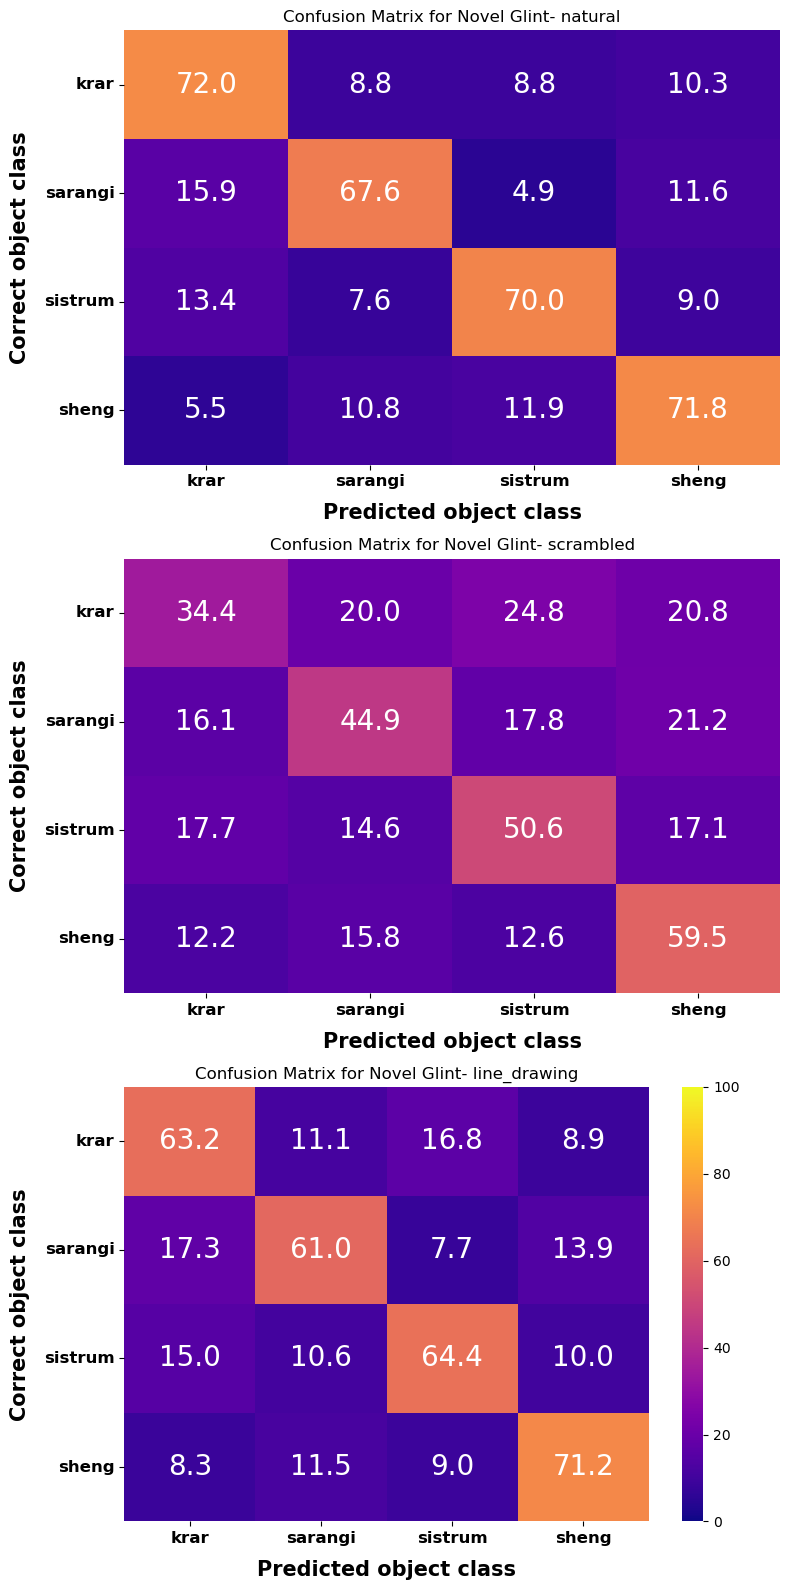

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

novel_objects = ['krar', 'sarangi', 'sistrum', 'sheng']

conditions = ['natural', 'scrambled', 'line_drawing']

fig, axes = plt.subplots(3, 1, figsize=(8, 16), sharey=True)

for ax, condition_name in zip(axes, conditions):
    condition_data = sub_summary[sub_summary['condition'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=novel_objects, columns=novel_objects, fill_value=0)

    response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

    sns.heatmap(
        response_percent,
        ax=ax,
        cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
        vmin=0,
        vmax=100,
        annot=True,
        fmt='.1f',
        annot_kws={'fontsize':20},
        cbar=ax is axes[-1]        
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12, fontweight='bold')  # Rotate y-axis labels to horizontal
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12, fontweight='bold')  # Rotate x-axis labels for better readability
    ax.set_title(f'Confusion Matrix for Novel Glint- {condition_name}')
    ax.set_xlabel('Predicted object class', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Correct object class', fontsize=15, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

## Child confusion Matrix (under construction!!!)

In [ ]:
import glob
import pandas as pd

experiment = 'familiar' # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes


# Define the paths 
base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

# participants we excluded in our original analysis
excluded_participants = []

# List of object classes in the experiment, which we will loop through to create summary dataframes for each object class
objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

# Initialize empty dataframe
participant_summary_df = pd.DataFrame()

sub_summary = pd.DataFrame()

base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
# import the files
files = glob.glob(f'{core_path}/*.csv') 
print(f"You have selected {experiment} glint experiment")


    
for obj in objects:
    for file in files:

        # Take the data for one participant at a time
        data = pd.read_csv(file)

        # Check if the participant is in the excluded list
        if data.loc[0, 'participant'] in excluded_participants:
            continue # skip this participant if they are in the excluded list
        

        '''        
        We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
        Exclusion criteria 1: Remove No responses
        Exclusion criteria 2: Remove RTs less than or equal to 100ms
        Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        
        '''
        # Exclusion criteria 1: Remove No responses
        data_exclusion_1 = data[data['response_label'] != 'no_response']

        # Exclusion criteria 2: Remove RTs less than or equal to 100ms
        data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

        # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        rt_mean = data_exclusion_2['key_resp.rt'].mean()
        rt_std = data_exclusion_2['key_resp.rt'].std()
        data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]



        # Filter for the current object class
        if experiment == 'familiar':
            object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
        
        
        # Extract only the columns you want
        if experiment == 'familiar':
            subset = object_trials[[
                'participant',
                'img_condition', # condition (natural, scrambled, line_drawing)
                'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                'key_resp.keys', # The actual key they pressed for their response
                #'object_class', # The object class of the image they were shown (ex: airplane, car, etc.)
                'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                'prompt_2', 
                'prompt_3', 
                'prompt_4', 
                'prompt_5', 
                'prompt_6', 
                'prompt_7', 
                'prompt_8', 
                'prompt_9']].copy()
            
        if experiment == 'novel':
            subset = object_trials[[
                'participant',
                'response_label', 
                'key_resp.corr', 
                'key_resp.keys', 
                'img_condition', 
                'img_class',
                'prompt_1',
                'prompt_2',
                'prompt_3',
                'prompt_4']].copy()
            
        column_map = {
            "reponse_label": "response_by_subject",
            "key_resp.corr": "correct (0=incorrect, 1=correct)",
            "key_resp.keys": "keyboard_response",
            "img_condition": "condition_block",
            "object_category": "correct_animacy",
            "img_class": "correct_object_class",
            "object_class": "correct_object_class"}

        #rename the colimns to standardize across experiment versions
        data = subset.rename(columns=column_map)

        
        # Append to the summary list
        participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe



    # Combine all into one dataframe
    sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)


## Model Confusion Matrix

As most of the preprocessing is already done in my modeling script, we can just take the all_models_raw.csv file. Then we will just need to swap some of the variable names to match the names I had in the modelling script.

### Define the path and read in the data

In [4]:
familiar_path = '/zpool/vladlab/data_drive/glint_master/data/model_data/familiar/models_combined/adult_familiar_all_models_raw_v2.csv'

familiar_df = pd.read_csv(familiar_path)
print(familiar_df.head(1))
models = familiar_df['id'].unique()
print(models)


         id classifier experiment_label  number_of_train_imgs condition  \
0  convnext        KNN         familiar                   300   natural   

  test_obj       animacy    obj1      obj2   obj3  ...        obj5 obj6  obj7  \
0     bear  anim_natural  teapot  mushroom  bread  ...  binoculars  cow  bear   

        obj8       obj9  panel_seed  vote_method filtered_acc  pred_label  \
0  lawnmower  pineapple  1085006768      invdist          1.0        bear   

  adult_or_child  
0          adult  

[1 rows x 21 columns]
['convnext' 'vit']


### Generate the Confusion matrix

In [5]:
import pandas as pd
import numpy as np

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']

for condition_name in conditions:
    for model in models:
            
        condition_data = familiar_df[(familiar_df['condition'] == condition_name) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        row_totals = counts.sum(axis=1)
        response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

        if condition_name == 'natural':
            confusion_matrix = response_percent.round(1)
        
        elif condition_name == 'shape':
            confusion_matrix_scrambled = response_percent.round(1)

        elif condition_name == 'feature':
            confusion_matrix_line_drawing = response_percent.round(1)
        print(model)
        print(condition_name)
        print(response_percent.round(1))
        print("Row sums:")
        print(response_percent.sum(axis=1).round(1))
        print()

convnext
natural
pred_label  airplane  apple  avocado   bear  binoculars  bread  butterfly  \
test_obj                                                                    
airplane       100.0    0.0      0.0    0.0         0.0    0.0        0.0   
apple            0.0  100.0      0.0    0.0         0.0    0.0        0.0   
avocado          0.0    0.0    100.0    0.0         0.0    0.0        0.0   
bear             0.0    0.0      0.0  100.0         0.0    0.0        0.0   
binoculars       0.0    0.0      0.0    0.0       100.0    0.0        0.0   
bread            0.0    0.0      0.0    0.0         0.0  100.0        0.0   
butterfly        0.0    0.0      0.0    0.0         0.0    0.0      100.0   
car              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cat              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
corn             0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cow              0.0    0.0      0.0    0.0         0.0    

### Let's plot it as a figure

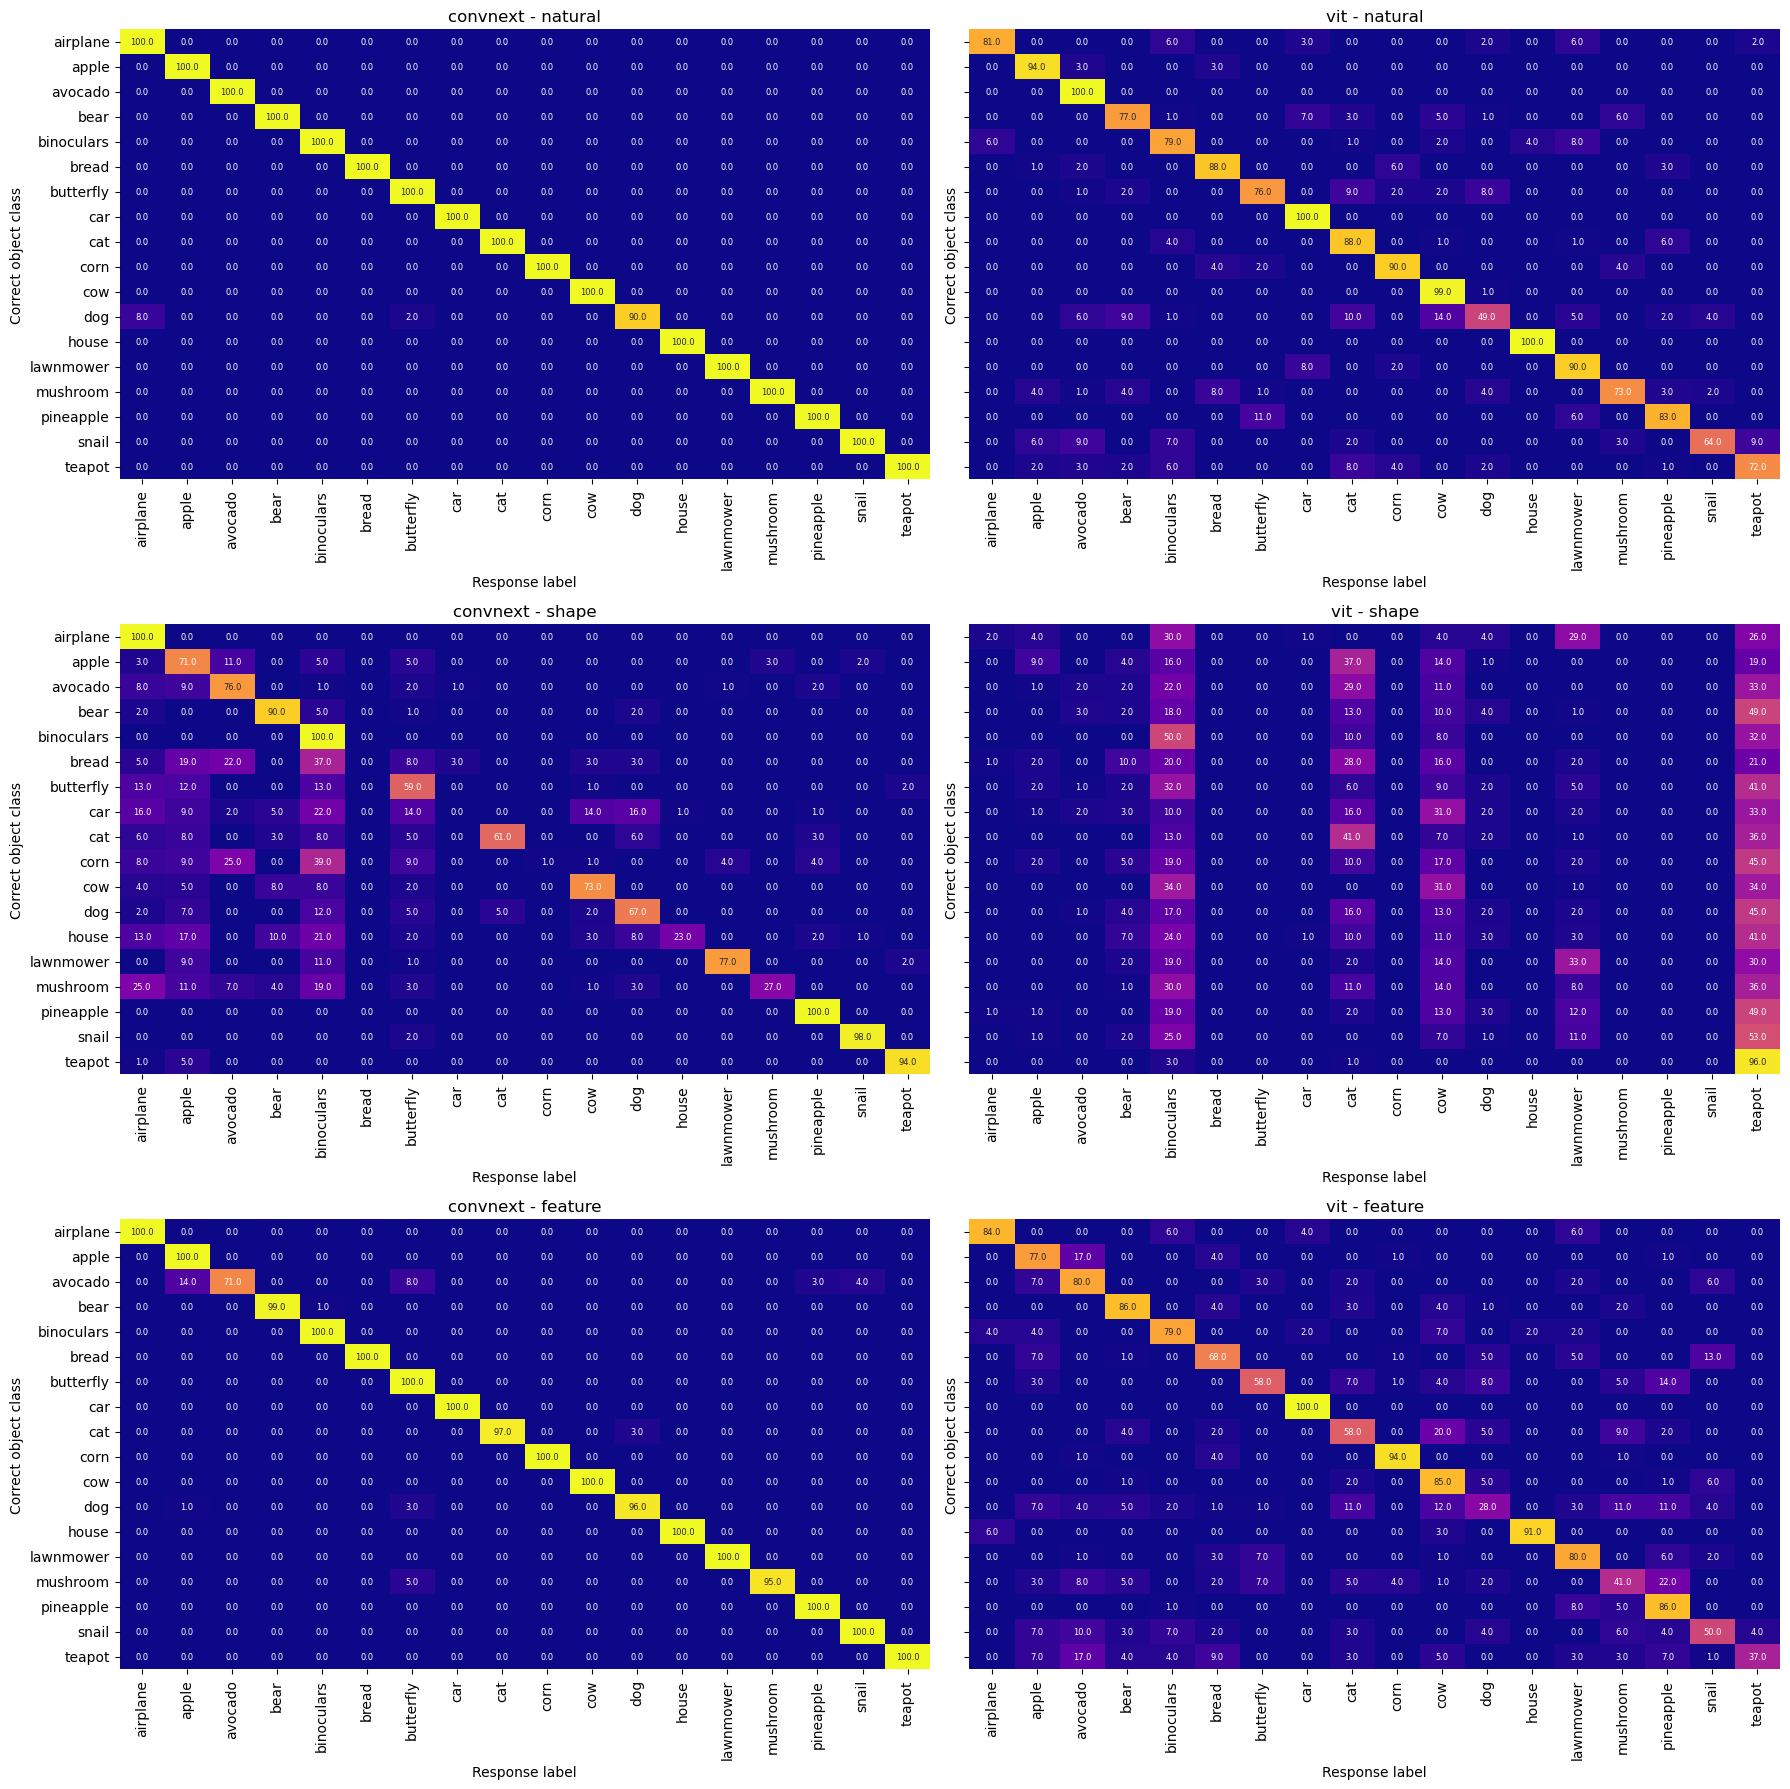

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']


fig, axes = plt.subplots(len(conditions), len(models), figsize=(18, 18), sharey=True)

for i, condition in enumerate(conditions):
    for j, model in enumerate(models):
        ax = axes[i, j]
        condition_data = familiar_df[(familiar_df['condition'] == condition) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

        sns.heatmap(
            response_percent,
            ax=ax,
            cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
            vmin=0,
            vmax=100,
            annot=True,
            fmt='.1f',
            annot_kws={'fontsize':6},
            cbar=ax is axes[-1]
            
        )

        ax.set_title(f'{model} - {condition}')
        ax.set_xlabel('Response label')
        ax.set_ylabel('Correct object class')

plt.tight_layout()
plt.show()